# Klasyfikacja sentymentu przy użyciu modeli sekwencyjnych
## Zbiór danych: Sentiment and Emotion Analysis Dataset (Kaggle)
### Modele: SimpleRNN, GRU, LSTM, BiLSTM, Conv1D, DistilBERT, DistilRoBERTa

**Zadanie:** Binarna klasyfikacja sentymentu (pozytywny / negatywny) na krótkich tekstach z mediów społecznościowych.  
Etykiety emocji są 6-klasowe (radość, smutek, złość, strach, zaskoczenie, odraza); Wybrałem sentyment, ponieważ  
setup binarny umożliwia czystsze porównanie między modelami, a nierównoważność klas jest mniejsza.

Link do datasetu: https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset


## 1. Importy


In [1]:
import torch; 

print("torch:", torch.__version__)
print("cuda_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu_0:", torch.cuda.get_device_name(0))
    print("cuda_version:", torch.version.cuda)

torch: 2.7.0+cu128
cuda_available: True
device_count: 1
gpu_0: NVIDIA GeForce RTX 4060
cuda_version: 12.8


In [2]:
import tensorflow as tf
import keras

tf.config.optimizer.set_jit(True)
tf.config.set_visible_devices([], 'GPU')

print("tf", tf.__version__)
print("keras", keras.__version__)
print("built_with_cuda:", tf.test.is_built_with_cuda())
print("gpus:", tf.config.list_physical_devices('GPU'))

2026-09-18 15:41:00.836319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789738860.934769   70777 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789738860.965778   70777 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789738861.118550   70777 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789738861.118598   70777 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789738861.118600   70777 computation_placer.cc:177] computation placer alr

tf 2.19.1
keras 3.12.4
built_with_cuda: True
gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os, json, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

print("Imports OK")


Imports OK


## 2. Konfiguracja i sciezki


In [4]:
RESULTS_DIR = "results"
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
HISTORIES_DIR = os.path.join(RESULTS_DIR, "histories")
LOGS_DIR = os.path.join(RESULTS_DIR, "logs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(HISTORIES_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


## 3. Wczytanie danych

In [5]:
DATA_DIR = os.path.join("..", "data", "ex3_data")
DATASET_PATH = os.path.join(DATA_DIR, "combined_sentiment_data.csv")
df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
df.head()


Shape: (3309, 2)

Columns: ['sentence', 'sentiment']

First rows:


,sentence,sentiment
0,So there is no way for me to plug it in here i...,negative
1,"Good case, Excellent value.",positive
2,Great for the jawbone.,positive
3,Tied to charger for conversations lasting more...,negative
4,The mic is great.,positive


## 4. Eksploracyjna analiza danych (EDA)


In [6]:
text_col = "sentence"
label_col = "sentiment"

print(f"Text column: '{text_col}'")
print(f"Label column: '{label_col}'")
print()
print("Label distribution:")
print(df[label_col].value_counts())


Text column: 'sentence'
Label column: 'sentiment'

Label distribution:
sentiment
positive    1679
negative    1630
Name: count, dtype: int64


In [7]:
# Drop rows with missing values in relevant columns
df = df[[text_col, label_col]].dropna()
df.columns = ["text", "label"]
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 3].reset_index(drop=True)

print("Clean dataset shape:", df.shape)


Clean dataset shape: (3309, 2)


In [8]:
# Keep only binary sentiment: positive / negative
mapping = {}
for v in df["label"].unique():
    v_str = str(v).lower().strip()
    if v_str in ("positive", "pos", "1", "1.0"):
        mapping[v] = 1
    elif v_str in ("negative", "neg", "0", "0.0"):
        mapping[v] = 0

df = df[df["label"].isin(mapping.keys())].copy()
df["label"] = df["label"].map(mapping)
print("After binary filter:", df.shape)
print("Class balance:")
print(df["label"].value_counts())


After binary filter: (3309, 2)
Class balance:
label
1    1679
0    1630
Name: count, dtype: int64


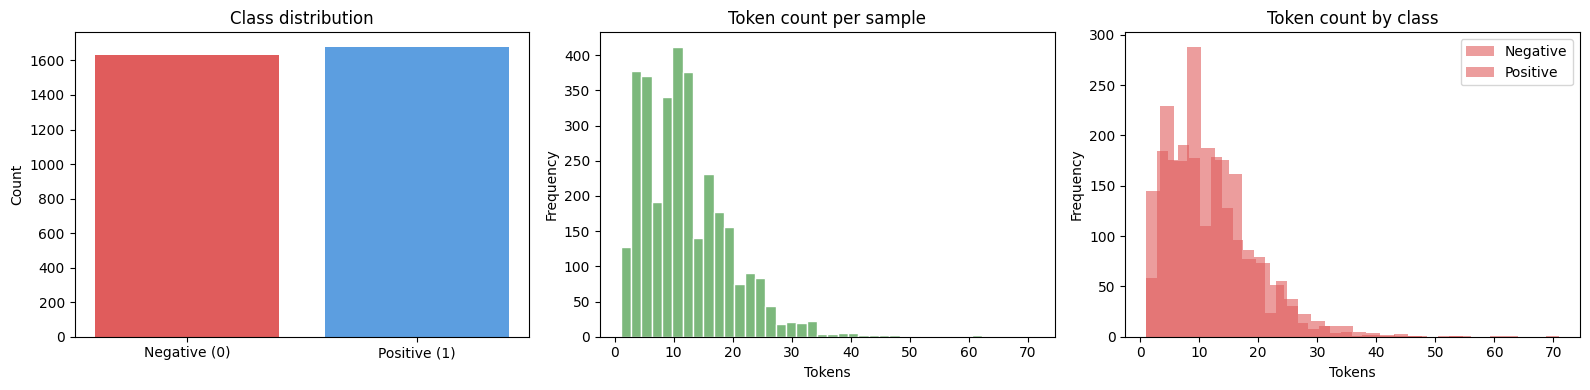

Avg tokens: 11.9, Max: 71, Min: 1


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df["label"].value_counts()
axes[0].bar(["Negative (0)", "Positive (1)"], [counts.get(0, 0), counts.get(1, 0)], color=["#e05c5c", "#5c9ee0"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")

# Text length distribution
df["text_len"] = df["text"].str.split().str.len()
axes[1].hist(df["text_len"], bins=40, color="#7cb87c", edgecolor="white")
axes[1].set_title("Token count per sample")
axes[1].set_xlabel("Tokens")
axes[1].set_ylabel("Frequency")

# Text length by class
df.groupby("label")["text_len"].plot.hist(alpha=0.6, bins=30, ax=axes[2], color=["#e05c5c", "#5c9ee0"])
axes[2].set_title("Token count by class")
axes[2].set_xlabel("Tokens")
axes[2].legend(["Negative", "Positive"])

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_overview.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Avg tokens: {df['text_len'].mean():.1f}, Max: {df['text_len'].max()}, Min: {df['text_len'].min()}")


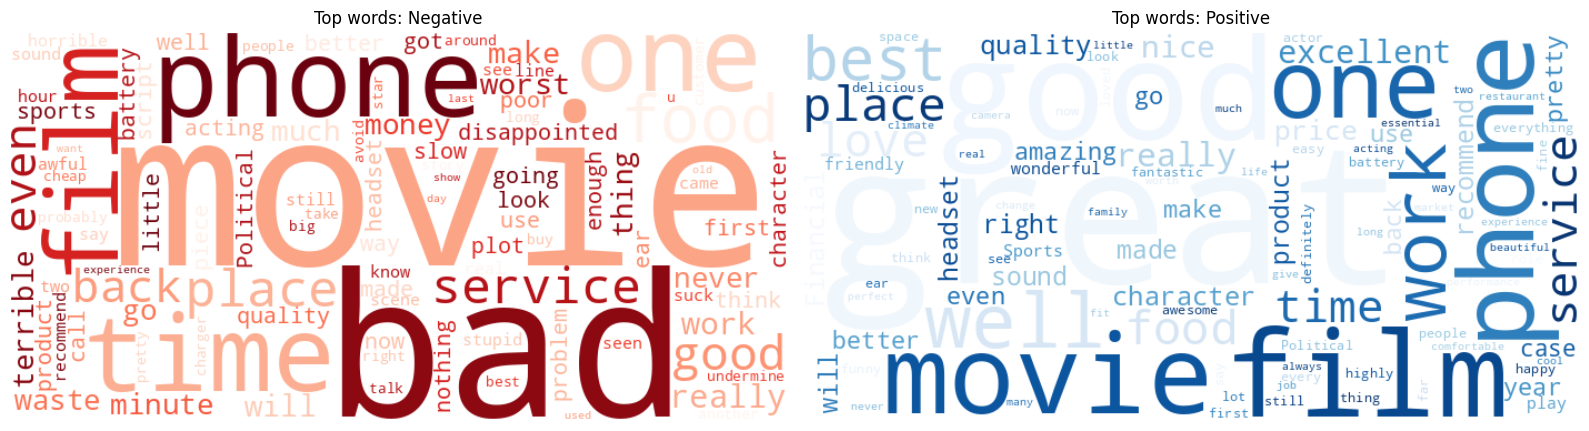

In [10]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cls, color, name in zip(axes, [0, 1], ["Reds", "Blues"], ["Negative", "Positive"]):
    texts = " ".join(df[df["label"] == cls]["text"].tolist())
    wc = WordCloud(width=700, height=350, background_color="white", colormap=color,
                   max_words=100, collocations=False).generate(texts)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Top words: {name}")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "wordcloud.png"), dpi=120, bbox_inches="tight")
plt.show()


**Wnioski z EDA:**
- Zbiór danych zawiera krótkie teksty w stylu mediów społecznościowych (zazwyczaj poniżej 30 tokenów - średnia koło 12).
- Klasy są zrównoważone


## 5. Wstępne przetwarzanie tekstu i kodowanie


In [11]:
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)            # remove mentions and hashtags
    text = re.sub(r"[^a-z0-9\s!?.,']", " ", text)    # keep basic punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean_text)
df = df[df["text_clean"].str.len() > 3].reset_index(drop=True)

# Train/val/test split: 70/15/15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    df["text_clean"].values, df["label"].values,
    test_size=0.15, random_state=42, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=0.15/0.85, random_state=42, stratify=y_tmp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 2313, Val: 496, Test: 496


In [12]:
# Tokenization for Keras models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)

MAX_VOCAB = 20000
MAX_LEN   = 64

tokenizer_keras = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(X_train)

def encode(texts):
    seqs = tokenizer_keras.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer_keras.word_index) + 1)
print(f"Vocab size: {VOCAB_SIZE}, Sequence length: {MAX_LEN}")
print(f"X_train shape: {X_train_enc.shape}")

Vocab size: 4970, Sequence length: 64
X_train shape: (2313, 64)


In [13]:
# One-hot encoded version (for SimpleRNN one-hot experiment)
from tensorflow.keras.utils import to_categorical

ONEHOT_VOCAB = 2000
ONEHOT_LEN   = 16

tokenizer_oh = Tokenizer(num_words=ONEHOT_VOCAB, oov_token="<OOV>")
tokenizer_oh.fit_on_texts(X_train)

def encode_oh(texts):
    seqs = tokenizer_oh.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=ONEHOT_LEN, padding="post", truncating="post")
    return to_categorical(padded, num_classes=ONEHOT_VOCAB).astype("float32")

X_train_oh = encode_oh(X_train)
X_val_oh   = encode_oh(X_val)
X_test_oh  = encode_oh(X_test)

print("One-hot train shape:", X_train_oh.shape)


One-hot train shape: (2313, 16, 2000)


**Uwagi dot. przetwarzania wstępnego:**
- Usunięto URL-e, wzmianki i hashtagi, ponieważ nie niosą sygnału semantycznego dla sentymentu.
- MAX_LEN=64 obejmuje zdecydowaną większość próbek bez nadmiernego paddingu.


## 6. Funkcje pomocnicze i konfiguracja punktów kontrolnych


In [14]:
import os
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping, ReduceLROnPlateau)

results = {}  # stores final metrics for all models

def get_callbacks(name):
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name}.keras")
    return [
        ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, verbose=0),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=0)
    ]

def evaluate_keras(model, X_te, y_te, name, history):
    
    y_prob = model.predict(X_te, verbose=0).ravel()

    print(y_prob[:20])
    print("min:", y_prob.min())
    print("max:", y_prob.max())
    print("mean:", y_prob.mean())
    
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    results[name] = {
        "accuracy": acc, "f1": f1, 
        "precision": prec, 
        "recall": rec,
        "history": history.history
    }
    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}")
    return y_pred

def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{name}: accuracy per epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{name}: loss per epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"history_{name.replace(' ', '_')}.png"), dpi=100, bbox_inches="tight")
    plt.show()

def plot_confusion(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix: {name}")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"cm_{name.replace(' ', '_')}.png"), dpi=100, bbox_inches="tight")
    plt.show()

print("Helpers defined. Checkpoints will be saved to:", CHECKPOINT_DIR)


Helpers defined. Checkpoints will be saved to: results/checkpoints


In [15]:
EMBED_DIM  = 128
HIDDEN_DIM = 128
EPOCHS     = 20
BATCH_SIZE = 64

# Class weights for imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHTS = {0: cw[0], 1: cw[1]}
print("Class weights:", CLASS_WEIGHTS)


Class weights: {0: 1.0144736842105264, 1: 0.9859335038363172}


## 7. Definicje architektur modeli sekwencyjnych

Poniżej definiuję funkcje budujące każdą architekturę. **Żaden model nie jest tu trenowany** —   
trening odbywa się dopiero po przeszukiwaniu hiperparametrów,   
gdzie każdy model jest trenowany z optymalną konfiguracją znalezioną przez grid search.  


### Model A: Kodowanie one-hot + SimpleRNN

Model bazowy. Każdy token jest reprezentowany jako wektor one-hot o rozmiarze VOCAB.  
Jest to najprostsza możliwa reprezentacja sekwencyjna — bez uczonych embeddingów.

**Architektura:** `Input(one-hot) → SimpleRNN(h) → Dropout → Dense(1, sigmoid)`  
**Wady:** pamięciochłonne, brak semantyki, zanikający gradient.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, GRU, LSTM, Bidirectional, Dense, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dropout, Input, RNN, GRUCell, LSTMCell)
import itertools, time

def build_oh_rnn(hidden_dim, dropout, **kwargs):
    """OneHot + SimpleRNN. embed_dim ignorowany — wejście to one-hot."""
    m = Sequential([
        Input(shape=(ONEHOT_LEN, ONEHOT_VOCAB)),
        SimpleRNN(hidden_dim, activation="tanh"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"OneHot_RNN_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_oh_rnn zdefiniowany.")
build_oh_rnn(32, 0.3).summary()


build_oh_rnn zdefiniowany.


Model: "OneHot_RNN_h32_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │        65,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model B: Embedding + SimpleRNN

Uczalne gęste embeddingi zastępują rzadką reprezentację one-hot.  
Warstwa embeddingów rzutuje każdy token w niskodymensjonalną ciągłą przestrzeń,  
pozwalając modelowi uczyć się semantycznych relacji między słowami.

**Architektura:** `Embedding(V,e) → SimpleRNN(h) → Dropout → Dense(1, sigmoid)`  
**Wniosek:** pamięciowo znacznie lepiej one-hot


In [17]:
def build_embed_rnn(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + SimpleRNN."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, mask_zero=True),
        SimpleRNN(hidden_dim, activation="tanh"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"Embed_RNN_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_embed_rnn zdefiniowany.")
build_embed_rnn(64, 64, 0.3).summary()


build_embed_rnn zdefiniowany.


Model: "Embed_RNN_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model C: Embedding + GRU

GRU dodaje dwa mechanizmy bramkowania (bramka resetowania i bramka aktualizacji),  
które regulują, ile informacji z przeszłości zachować. Mniej parametrów niż LSTM,  
często zbiega szybciej i osiąga porównywalną dokładność.

**Architektura:** `Embedding(V,e) → GRU(h, dropout) → Dense(32, relu) → Dense(1, sigmoid)`


In [18]:
def build_gru(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + GRU."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, mask_zero=True),
        GRU(hidden_dim),                 
        Dropout(dropout),           
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ], name=f"GRU_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_gru zdefiniowany.")
build_gru(64, 64, 0.3).summary()


build_gru zdefiniowany.


Model: "GRU_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model D: Embedding + LSTM

LSTM rozszerza RNN o dedykowany stan komórki (pamięć długoterminowa) i trzy bramki  
(zapominania, wejścia, wyjścia). Stan komórki pozwala informacjom utrzymywać się  
przez wiele kroków czasowych z minimalną degradacją gradientu.

**Architektura:** `Embedding(V,e) → LSTM(h, dropout) → Dense(32, relu) → Dropout → Dense(1, sigmoid)`


In [19]:
def build_lstm(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + LSTM."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, mask_zero=True),
        LSTM(hidden_dim),           
        Dropout(dropout),         
        Dense(32, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"LSTM_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_lstm zdefiniowany.")
build_lstm(64, 64, 0.3).summary()


build_lstm zdefiniowany.


Model: "LSTM_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model E: Bidirectional LSTM

BiLSTM uruchamia dwie warstwy LSTM: jedną w przód (lewo-prawo) i jedną wstecz (prawo-lewo).  
Oba ukryte stany są konkatenowane, dając modelowi pełny lewy i prawy kontekst na każdej pozycji.  

**Architektura:** `Embedding → Bidirectional(LSTM(h)) → Dense(64, relu) → Dropout → Dense(1, sigmoid)`


In [20]:
def build_bilstm(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + Bidirectional LSTM."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim),
        Bidirectional(LSTM(hidden_dim)),
        Dropout(dropout),
        Dense(64, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"BiLSTM_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4), loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_bilstm zdefiniowany.")
build_bilstm(64, 64, 0.3).summary()


build_bilstm zdefiniowany.


Model: "BiLSTM_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model F: Embedding + Conv1D

Sploty 1D przesuwają jądro wzdłuż sekwencji i wykrywają lokalne wzorce n-gramów.  
GlobalMaxPooling wybiera najbardziej aktywowaną cechę spośród wszystkich pozycji.  
Jest szybki, paralolizowalny i nie wymaga pamięci sekwencyjnej.

**Architektura:** `Embedding → Conv1D(h,3) → Conv1D(h/2,3) → GlobalMaxPool → Dense(64) → Dropout → Dense(1)`


In [21]:
def build_conv1d(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + Conv1D (dwie warstwy splotowe)."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, mask_zero=True),
        Conv1D(hidden_dim, 3, activation="relu"),
        Conv1D(hidden_dim // 2, 3, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"Conv1D_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_conv1d zdefiniowany.")
build_conv1d(64, 64, 0.3).summary()


build_conv1d zdefiniowany.


Model: "Conv1D_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model G: Conv1D + LSTM (hybrydowy)

Conv1D najpierw wyodrębnia lokalne cechy (wzorce n-gramów), następnie LSTM modeluje  
zależności czasowe między tymi cechami. MaxPooling po Conv1D skraca sekwencję przed LSTM.  

**Architektura:** `Embedding → Conv1D(h,3,same) → MaxPool(2) → LSTM(h/2) → Dense(32) → Dropout → Dense(1)`


In [22]:
def build_conv_lstm(embed_dim, hidden_dim, dropout, **kwargs):
    """Embedding + Conv1D + LSTM (hybrydowy)."""
    m = Sequential([
        Embedding(VOCAB_SIZE, embed_dim, mask_zero=True),
        Conv1D(hidden_dim, 3, activation="relu", padding="same"),
        MaxPooling1D(2),
        LSTM(hidden_dim // 2),  #, dropout=dropout
        Dense(32, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ], name=f"Conv1D_LSTM_e{embed_dim}_h{hidden_dim}_d{int(dropout*10)}")
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

print("build_conv_lstm zdefiniowany.")
build_conv_lstm(64, 64, 0.3).summary()


build_conv_lstm zdefiniowany.


Model: "Conv1D_LSTM_e64_h64_d3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Podsumowanie architektur:**  
Wszystkie siedem funkcji `build_*` jest gotowych.

## 8. Przeszukiwanie hiperparametrów — wszystkie modele

Przeprowadzamy przeszukiwanie siatki dla każdej architektury. Przestrzeń hiperparametrów:  
- `embed_dim ∈ [64, 128]` (dla modeli embeddingowych)  
- `hidden_dim ∈ [64, 128]`  
- `dropout ∈ [0.2, 0.4]`  
- `batch_size ∈ [32, 64]`  

Po znalezieniu najlepszej konfiguracji każdy model jest trenowany ponownie z pełną  
liczbą epok i wczytaniem najlepszych wag (`ModelCheckpoint`).


In [23]:
# ------------------------------------------------------------------ #
# Wspólna infrastruktura przeszukiwania                              #
# ------------------------------------------------------------------ #

EMBED_DIMS  = [64, 128]
HIDDEN_DIMS = [64, 128]
DROPOUTS    = [0.2, 0.4]
BATCH_SIZES = [32, 64]

all_search_results = {}   # { model_name -> DataFrame }

def run_grid_search(model_name, build_fn, X_tr, y_tr, X_va, y_va,
                    embed_dims=EMBED_DIMS, hidden_dims=HIDDEN_DIMS,
                    dropouts=DROPOUTS, batch_sizes=BATCH_SIZES,
                    search_epochs=12):
    """
    Przeszukuje siatkę i zwraca posortowany DataFrame.
    build_fn(embed_dim, hidden_dim, dropout) -> skompilowany model Keras
    """
    rows = []
    combos = list(itertools.product(embed_dims, hidden_dims, dropouts, batch_sizes))
    print(f"\n{'='*60}")
    print(f"Grid search: {model_name}  ({len(combos)} kombinacji)")
    print(f"{'='*60}")

    for ed, hd, dr, bs in combos:
        run_id = f"{model_name}_e{ed}_h{hd}_d{int(dr*10)}_b{bs}"
        m = build_fn(embed_dim=ed, hidden_dim=hd, dropout=dr)
        cb = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=3,
                restore_best_weights=True, verbose=0),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=2, verbose=0)
        ]
        t0 = time.time()
        h = m.fit(X_tr, y_tr,
                  validation_data=(X_va, y_va),
                  epochs=search_epochs, batch_size=bs,
                  callbacks=cb, class_weight=CLASS_WEIGHTS, verbose=0)
        elapsed = time.time() - t0

        best_ep   = int(np.argmax(h.history["val_accuracy"])) + 1
        val_acc   = float(np.max(h.history["val_accuracy"]))
        val_loss  = float(np.min(h.history["val_loss"]))
        n_ep      = len(h.history["val_accuracy"])

        rows.append({
            "run":         run_id,
            "embed_dim":  ed,
            "hidden_dim": hd,
            "dropout":    dr,
            "batch_size": bs,
            "val_accuracy":  val_acc,
            "val_loss":      val_loss,
            "best_epoch":    best_ep,
            "epochs_run":    n_ep,
            "time_s":        elapsed,
        })
        print(f"  {run_id:50s}  val_acc={val_acc:.4f}  best_ep={best_ep:2d}/{n_ep}  t={elapsed:.1f}s")

    df_res = (pd.DataFrame(rows)
                .sort_values("val_accuracy", ascending=False)
                .reset_index(drop=True))
    all_search_results[model_name] = df_res
    print(f"\nTop-3 dla {model_name}:")
    cols_show = ["run","val_accuracy","val_loss","embed_dim","hidden_dim","dropout","batch_size"]
    print(df_res.head(3)[cols_show].to_string(index=False))
    return df_res

print("run_grid_search gotowy.")


run_grid_search gotowy.


### 8.1 OneHot + SimpleRNN

In [24]:
# OneHot RNN: brak embed_dim — iterujemy po hidden i dropout
oh_rows = []
for hd, dr, bs in itertools.product(HIDDEN_DIMS, DROPOUTS, BATCH_SIZES):
    run_id = f"OneHot_RNN_h{hd}_d{int(dr*10)}_b{bs}"
    m = build_oh_rnn(hidden_dim=hd, dropout=dr)
    cb = [tf.keras.callbacks.EarlyStopping(
              monitor="val_loss", patience=3,
              restore_best_weights=True, verbose=0)]
    t0 = time.time()
    h = m.fit(X_train_oh, y_train,
              validation_data=(X_val_oh, y_val),
              epochs=12, batch_size=bs,
              callbacks=cb, class_weight=CLASS_WEIGHTS, verbose=0)
    elapsed = time.time() - t0
    val_acc  = float(np.max(h.history["val_accuracy"]))
    val_loss = float(np.min(h.history["val_loss"]))
    oh_rows.append({"run": run_id, "embed_dim": None,
                    "hidden_dim": hd, "dropout": dr, "batch_size": bs,
                    "val_accuracy": val_acc, "val_loss": val_loss,
                    "time_s": elapsed})
    print(f"  {run_id:45s}  val_acc={val_acc:.4f}  t={elapsed:.1f}s")

oh_df = (pd.DataFrame(oh_rows)
           .sort_values("val_accuracy", ascending=False)
           .reset_index(drop=True))
all_search_results["OneHot_RNN"] = oh_df
print("\nTop-3:")
print(oh_df.head(3)[["run","val_accuracy","hidden_dim","dropout","batch_size"]].to_string(index=False))


I0000 00:00:1789738872.603655   70827 service.cc:152] XLA service 0x7e295c00ac30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789738872.603830   70827 service.cc:160]   StreamExecutor device (0): Host, Default Version
2026-09-18 15:41:12.668304: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789738873.348191   70827 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  OneHot_RNN_h64_d2_b32                          val_acc=0.7621  t=9.9s
  OneHot_RNN_h64_d2_b64                          val_acc=0.7681  t=7.7s
  OneHot_RNN_h64_d4_b32                          val_acc=0.7319  t=9.6s
  OneHot_RNN_h64_d4_b64                          val_acc=0.7218  t=7.5s
  OneHot_RNN_h128_d2_b32                         val_acc=0.7540  t=8.6s
  OneHot_RNN_h128_d2_b64                         val_acc=0.7218  t=7.7s
  OneHot_RNN_h128_d4_b32                         val_acc=0.7419  t=9.2s
  OneHot_RNN_h128_d4_b64                         val_acc=0.7440  t=7.6s

Top-3:
                   run  val_accuracy  hidden_dim  dropout  batch_size
 OneHot_RNN_h64_d2_b64      0.768145          64      0.2          64
 OneHot_RNN_h64_d2_b32      0.762097          64      0.2          32
OneHot_RNN_h128_d2_b32      0.754032         128      0.2          32


### 8.2 Embedding + SimpleRNN

In [25]:
embed_rnn_df = run_grid_search(
    "Embed_RNN", build_embed_rnn,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: Embed_RNN  (16 kombinacji)
  Embed_RNN_e64_h64_d2_b32                            val_acc=0.7984  best_ep= 4/6  t=9.3s
  Embed_RNN_e64_h64_d2_b64                            val_acc=0.7883  best_ep= 5/8  t=9.7s
  Embed_RNN_e64_h64_d4_b32                            val_acc=0.7762  best_ep= 5/6  t=9.7s
  Embed_RNN_e64_h64_d4_b64                            val_acc=0.7460  best_ep= 5/5  t=6.9s
  Embed_RNN_e64_h128_d2_b32                           val_acc=0.7560  best_ep= 2/5  t=11.7s
  Embed_RNN_e64_h128_d2_b64                           val_acc=0.7601  best_ep= 3/4  t=8.7s
  Embed_RNN_e64_h128_d4_b32                           val_acc=0.8125  best_ep= 5/5  t=11.0s
  Embed_RNN_e64_h128_d4_b64                           val_acc=0.7480  best_ep= 5/5  t=12.8s
  Embed_RNN_e128_h64_d2_b32                           val_acc=0.7581  best_ep= 3/4  t=9.1s
  Embed_RNN_e128_h64_d2_b64                           val_acc=0.7843  best_ep= 5/8  t=11.7s
  Embed_RNN_e128_h64_d4_b32                  

### 8.3 GRU

In [26]:
gru_df = run_grid_search(
    "GRU", build_gru,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: GRU  (16 kombinacji)
  GRU_e64_h64_d2_b32                                  val_acc=0.8206  best_ep= 4/5  t=13.1s
  GRU_e64_h64_d2_b64                                  val_acc=0.8286  best_ep= 3/5  t=11.6s
  GRU_e64_h64_d4_b32                                  val_acc=0.8185  best_ep= 3/5  t=13.7s
  GRU_e64_h64_d4_b64                                  val_acc=0.8286  best_ep= 3/5  t=12.7s
  GRU_e64_h128_d2_b32                                 val_acc=0.8125  best_ep= 3/5  t=27.5s
  GRU_e64_h128_d2_b64                                 val_acc=0.8226  best_ep= 3/5  t=22.0s
  GRU_e64_h128_d4_b32                                 val_acc=0.8306  best_ep= 2/4  t=20.7s
  GRU_e64_h128_d4_b64                                 val_acc=0.8246  best_ep= 4/5  t=21.1s
  GRU_e128_h64_d2_b32                                 val_acc=0.8206  best_ep= 4/4  t=15.4s
  GRU_e128_h64_d2_b64                                 val_acc=0.8266  best_ep= 3/5  t=15.1s
  GRU_e128_h64_d4_b32                        

### 8.4 LSTM

In [27]:
lstm_df = run_grid_search(
    "LSTM", build_lstm,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: LSTM  (16 kombinacji)
  LSTM_e64_h64_d2_b32                                 val_acc=0.8206  best_ep= 7/7  t=20.1s
  LSTM_e64_h64_d2_b64                                 val_acc=0.8044  best_ep= 6/7  t=15.8s
  LSTM_e64_h64_d4_b32                                 val_acc=0.7923  best_ep= 3/6  t=18.9s
  LSTM_e64_h64_d4_b64                                 val_acc=0.7883  best_ep= 7/7  t=15.9s
  LSTM_e64_h128_d2_b32                                val_acc=0.8246  best_ep= 6/6  t=44.5s
  LSTM_e64_h128_d2_b64                                val_acc=0.8105  best_ep= 5/7  t=29.4s
  LSTM_e64_h128_d4_b32                                val_acc=0.8125  best_ep= 6/7  t=50.2s
  LSTM_e64_h128_d4_b64                                val_acc=0.8105  best_ep= 8/8  t=36.3s
  LSTM_e128_h64_d2_b32                                val_acc=0.8226  best_ep= 4/6  t=22.1s
  LSTM_e128_h64_d2_b64                                val_acc=0.8165  best_ep= 6/7  t=24.8s
  LSTM_e128_h64_d4_b32                      

### 8.5 BiLSTM

In [28]:
bilstm_df = run_grid_search(
    "BiLSTM", build_bilstm,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: BiLSTM  (16 kombinacji)
  BiLSTM_e64_h64_d2_b32                               val_acc=0.8327  best_ep= 4/7  t=37.2s
  BiLSTM_e64_h64_d2_b64                               val_acc=0.8286  best_ep= 7/9  t=46.2s
  BiLSTM_e64_h64_d4_b32                               val_acc=0.8347  best_ep= 7/7  t=35.7s
  BiLSTM_e64_h64_d4_b64                               val_acc=0.8488  best_ep= 9/9  t=42.9s
  BiLSTM_e64_h128_d2_b32                              val_acc=0.8347  best_ep= 5/6  t=81.2s
  BiLSTM_e64_h128_d2_b64                              val_acc=0.7460  best_ep= 3/6  t=61.7s
  BiLSTM_e64_h128_d4_b32                              val_acc=0.8347  best_ep= 7/7  t=88.9s
  BiLSTM_e64_h128_d4_b64                              val_acc=0.8367  best_ep= 8/8  t=73.2s
  BiLSTM_e128_h64_d2_b32                              val_acc=0.8226  best_ep= 6/6  t=48.0s
  BiLSTM_e128_h64_d2_b64                              val_acc=0.8468  best_ep= 6/8  t=51.4s
  BiLSTM_e128_h64_d4_b32                  

### 8.6 Conv1D

In [29]:
conv1d_df = run_grid_search(
    "Conv1D", build_conv1d,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: Conv1D  (16 kombinacji)
  Conv1D_e64_h64_d2_b32                               val_acc=0.8327  best_ep= 4/5  t=8.5s
  Conv1D_e64_h64_d2_b64                               val_acc=0.8306  best_ep= 6/6  t=7.2s
  Conv1D_e64_h64_d4_b32                               val_acc=0.8367  best_ep= 3/5  t=7.9s
  Conv1D_e64_h64_d4_b64                               val_acc=0.8246  best_ep= 4/6  t=7.1s
  Conv1D_e64_h128_d2_b32                              val_acc=0.8185  best_ep= 2/5  t=8.7s
  Conv1D_e64_h128_d2_b64                              val_acc=0.8266  best_ep= 6/6  t=8.2s
  Conv1D_e64_h128_d4_b32                              val_acc=0.8347  best_ep= 5/5  t=8.7s
  Conv1D_e64_h128_d4_b64                              val_acc=0.8286  best_ep= 3/6  t=9.5s
  Conv1D_e128_h64_d2_b32                              val_acc=0.8427  best_ep= 3/5  t=8.8s
  Conv1D_e128_h64_d2_b64                              val_acc=0.8165  best_ep= 4/6  t=8.2s
  Conv1D_e128_h64_d4_b32                            

### 8.7 Conv1D + LSTM

In [30]:
conv_lstm_df = run_grid_search(
    "Conv1D_LSTM", build_conv_lstm,
    X_train_enc, y_train, X_val_enc, y_val)



Grid search: Conv1D_LSTM  (16 kombinacji)
  Conv1D_LSTM_e64_h64_d2_b32                          val_acc=0.8024  best_ep= 8/10  t=23.7s
  Conv1D_LSTM_e64_h64_d2_b64                          val_acc=0.5081  best_ep= 1/4  t=12.2s
  Conv1D_LSTM_e64_h64_d4_b32                          val_acc=0.5081  best_ep= 2/5  t=15.1s
  Conv1D_LSTM_e64_h64_d4_b64                          val_acc=0.5081  best_ep= 1/4  t=11.6s
  Conv1D_LSTM_e64_h128_d2_b32                         val_acc=0.8165  best_ep= 8/9  t=36.2s
  Conv1D_LSTM_e64_h128_d2_b64                         val_acc=0.5081  best_ep= 1/4  t=20.1s
  Conv1D_LSTM_e64_h128_d4_b32                         val_acc=0.5081  best_ep= 1/4  t=19.3s
  Conv1D_LSTM_e64_h128_d4_b64                         val_acc=0.5081  best_ep= 2/5  t=22.9s
  Conv1D_LSTM_e128_h64_d2_b32                         val_acc=0.8165  best_ep= 9/10  t=24.6s
  Conv1D_LSTM_e128_h64_d2_b64                         val_acc=0.5081  best_ep= 1/4  t=13.9s
  Conv1D_LSTM_e128_h64_d4_b32      

### 8.8 Wizualizacja wyników przeszukiwania hiperparametrów

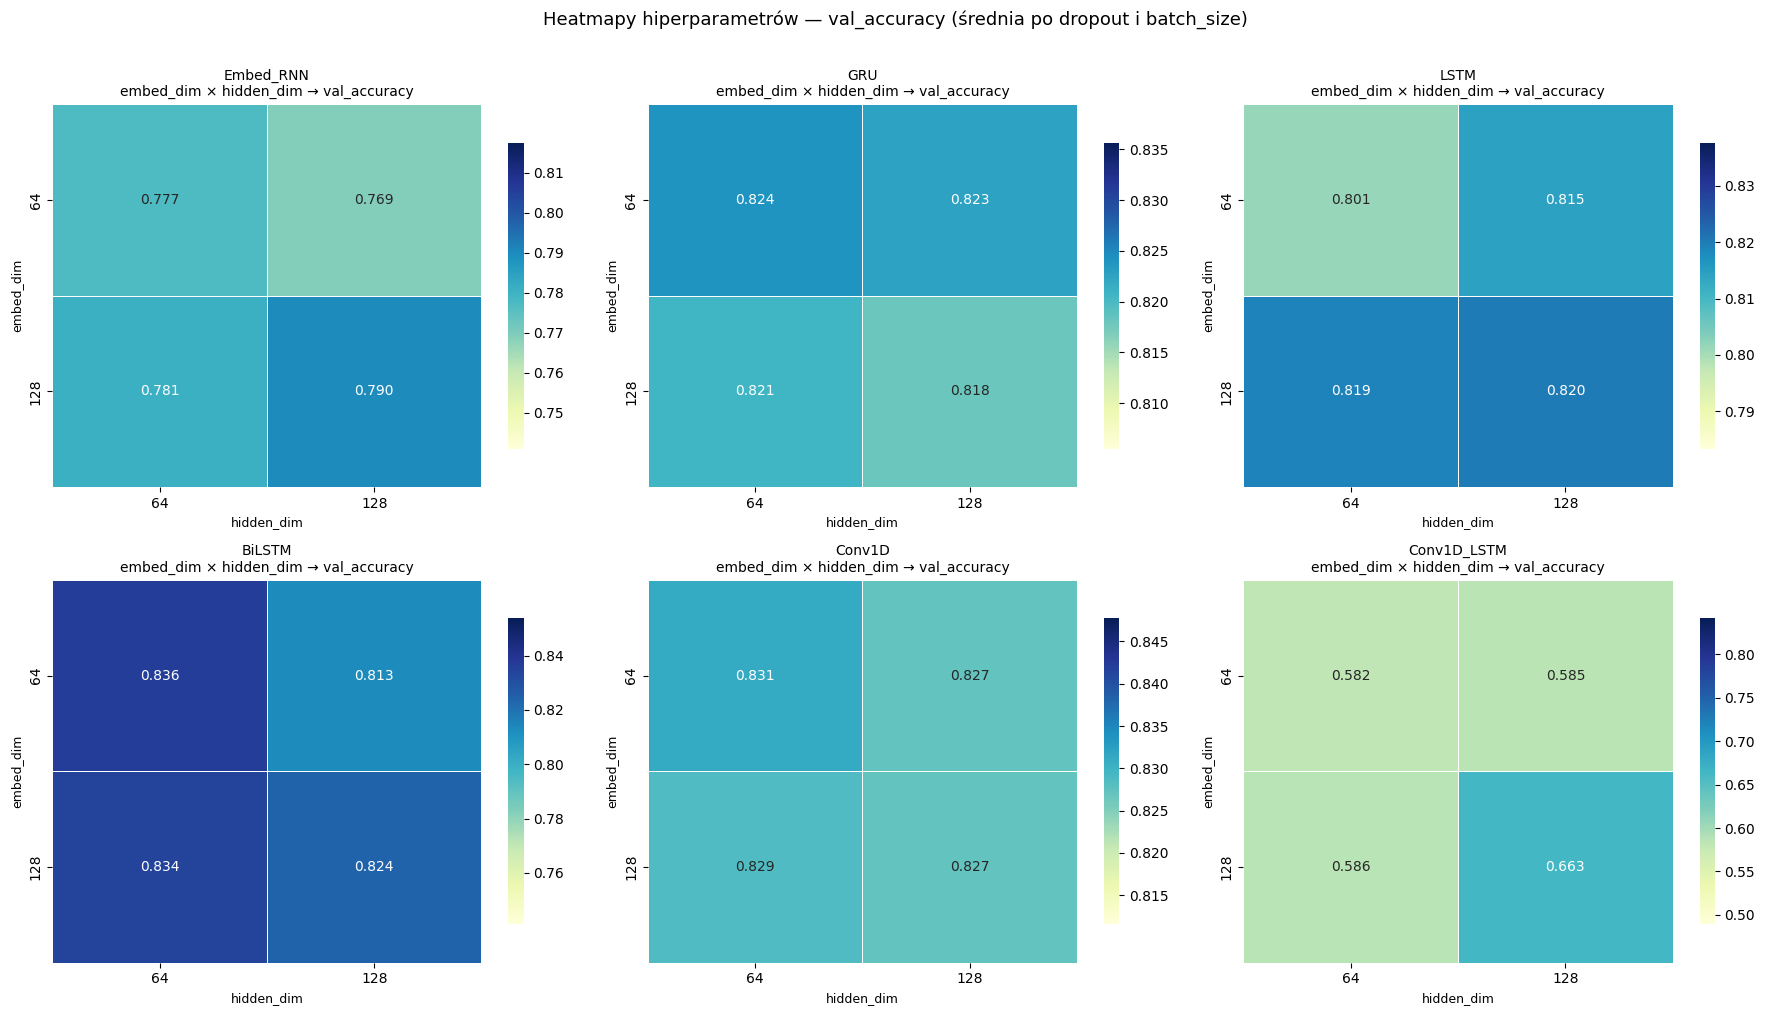

In [31]:
# Heatmapy embed_dim × hidden_dim dla modeli embeddingowych
embedding_models = ["Embed_RNN", "GRU", "LSTM", "BiLSTM", "Conv1D", "Conv1D_LSTM"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, model_name in zip(axes, embedding_models):
    df_m = all_search_results[model_name]
    pivot = df_m.pivot_table(
        values="val_accuracy",
        index="embed_dim", columns="hidden_dim", aggfunc="mean")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                vmin=df_m["val_accuracy"].min() - 0.005,
                vmax=df_m["val_accuracy"].max() + 0.005,
                ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{model_name}\nembed_dim × hidden_dim → val_accuracy", fontsize=10)
    ax.set_xlabel("hidden_dim", fontsize=9)
    ax.set_ylabel("embed_dim", fontsize=9)

plt.suptitle("Heatmapy hiperparametrów — val_accuracy (średnia po dropout i batch_size)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hparam_heatmaps_embed_hidden.png"), dpi=120, bbox_inches="tight")
plt.show()


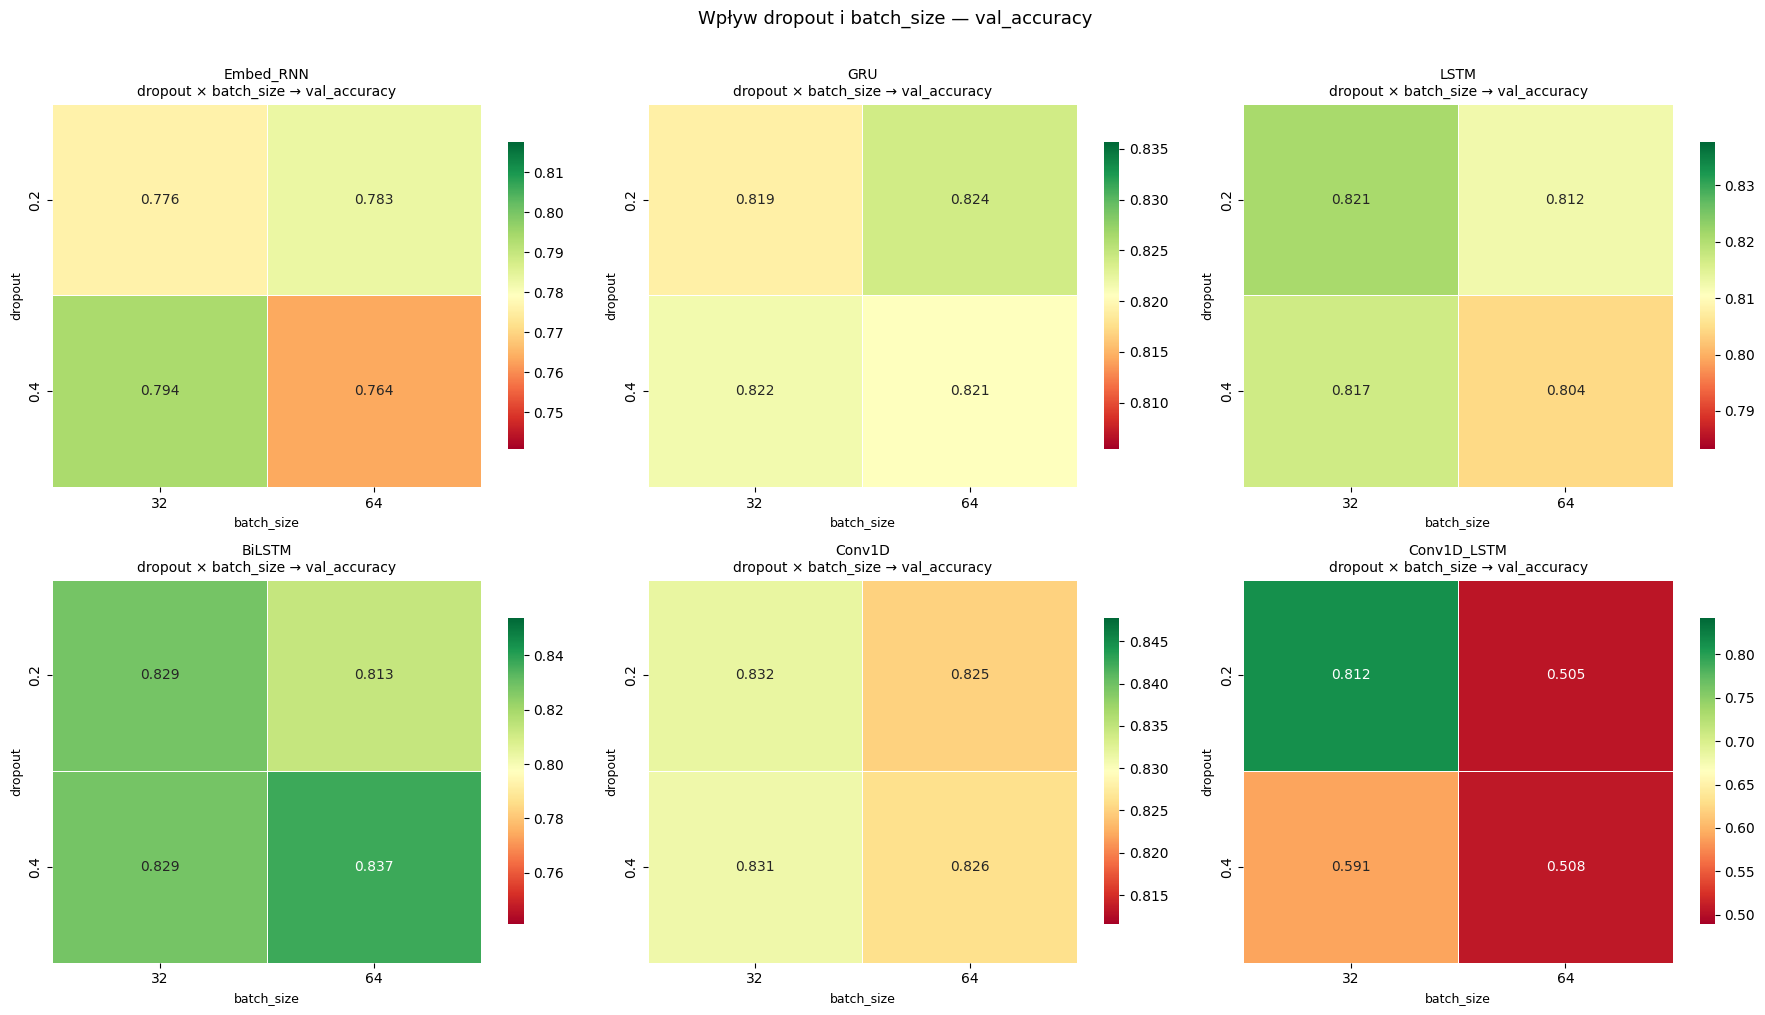

In [32]:
# Heatmapy dropout × batch_size
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, model_name in zip(axes, embedding_models):
    df_m = all_search_results[model_name]
    pivot = df_m.pivot_table(
        values="val_accuracy",
        index="dropout", columns="batch_size", aggfunc="mean")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=df_m["val_accuracy"].min() - 0.005,
                vmax=df_m["val_accuracy"].max() + 0.005,
                ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{model_name}\ndropout × batch_size → val_accuracy", fontsize=10)
    ax.set_xlabel("batch_size", fontsize=9)
    ax.set_ylabel("dropout", fontsize=9)

plt.suptitle("Wpływ dropout i batch_size — val_accuracy", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hparam_heatmaps_dropout_batch.png"), dpi=120, bbox_inches="tight")
plt.show()


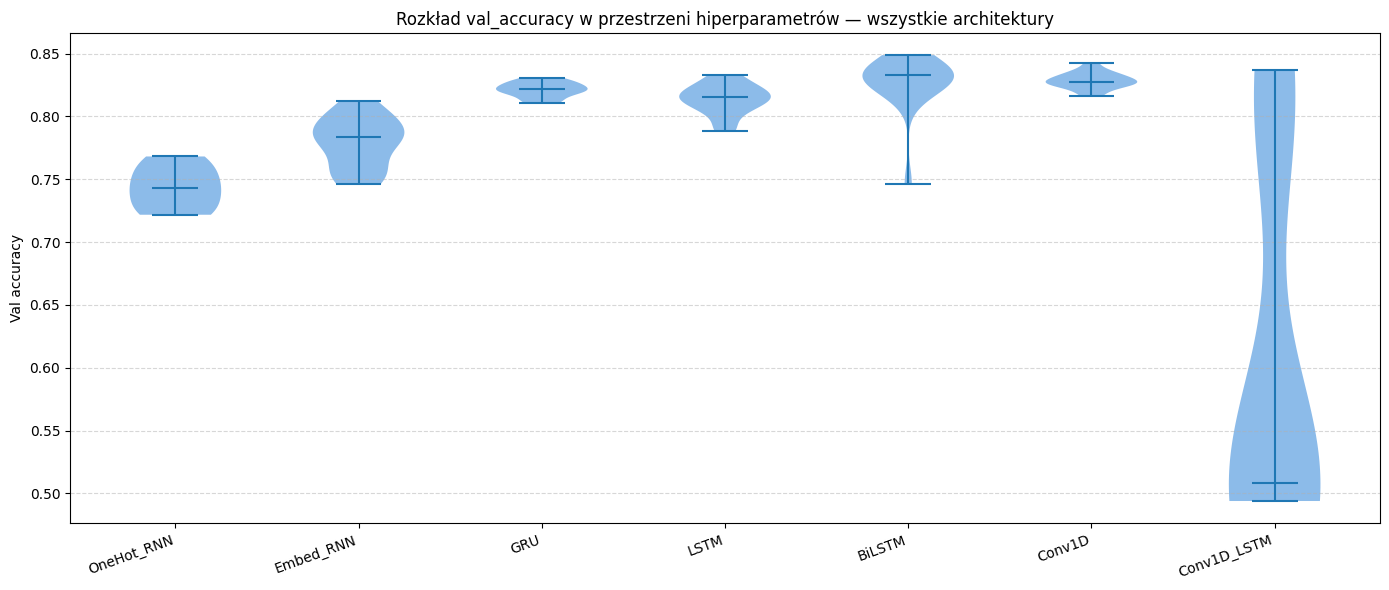

In [33]:
# Violin plot: rozkład val_accuracy dla każdej architektury
all_model_names = ["OneHot_RNN"] + embedding_models

fig, ax = plt.subplots(figsize=(14, 6))
all_vals = [all_search_results[n]["val_accuracy"].values for n in all_model_names]

parts = ax.violinplot(all_vals, positions=range(len(all_model_names)), showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor("#5c9ee0")
    pc.set_alpha(0.7)

ax.set_xticks(range(len(all_model_names)))
ax.set_xticklabels(all_model_names, rotation=20, ha="right")
ax.set_ylabel("Val accuracy")
ax.set_title("Rozkład val_accuracy w przestrzeni hiperparametrów — wszystkie architektury")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hparam_violin.png"), dpi=120, bbox_inches="tight")
plt.show()


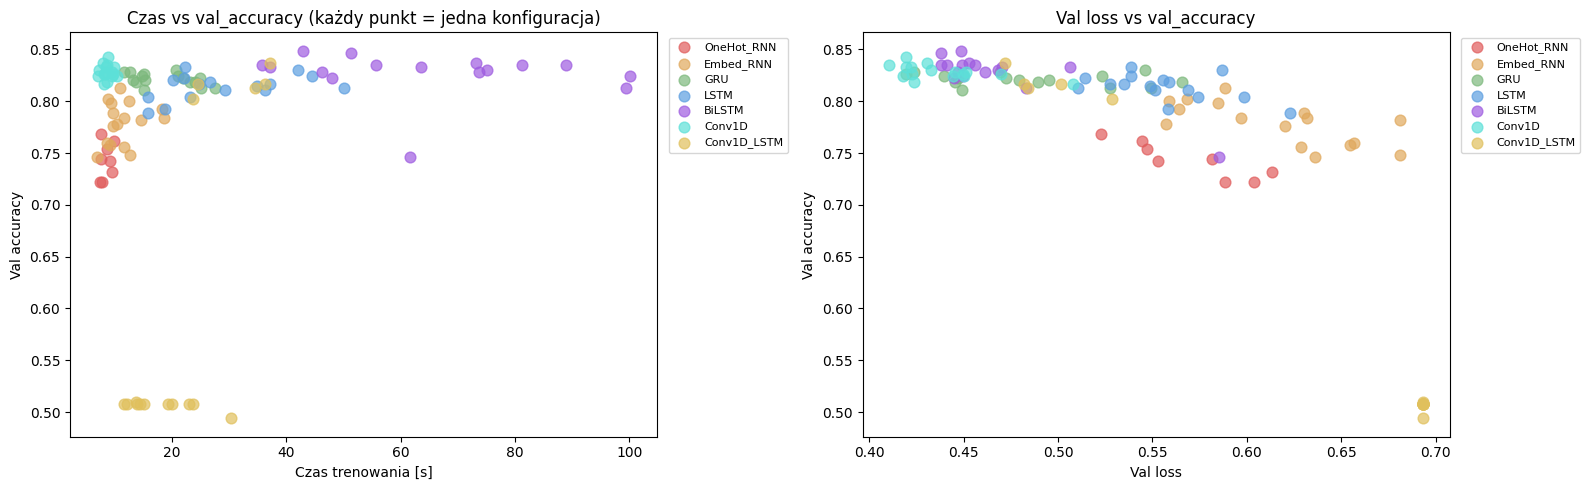

In [34]:
# Scatter: czas trenowania vs val_accuracy
colors_map = {
    "OneHot_RNN":  "#e05c5c",
    "Embed_RNN":   "#e0a85c",
    "GRU":         "#7cb87c",
    "LSTM":        "#5c9ee0",
    "BiLSTM":      "#9e5ce0",
    "Conv1D":      "#5ce0d8",
    "Conv1D_LSTM": "#e0c05c",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name in all_model_names:
    df_m = all_search_results[name]
    col  = colors_map.get(name, "gray")
    axes[0].scatter(df_m["time_s"],  df_m["val_accuracy"], label=name, alpha=0.7, s=60, color=col)
    axes[1].scatter(df_m["val_loss"], df_m["val_accuracy"], label=name, alpha=0.7, s=60, color=col)

axes[0].set_xlabel("Czas trenowania [s]"); axes[0].set_ylabel("Val accuracy")
axes[0].set_title("Czas vs val_accuracy (każdy punkt = jedna konfiguracja)")
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1))

axes[1].set_xlabel("Val loss"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Val loss vs val_accuracy")
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hparam_scatter.png"), dpi=120, bbox_inches="tight")
plt.show()


In [35]:
# Najlepsza konfiguracja każdej architektury — tabela podsumowująca
best_rows = []
for name in all_model_names:
    best = all_search_results[name].iloc[0]
    best_rows.append({
        "Architektura":  name,
        "embed_dim":     int(best["embed_dim"]) if pd.notna(best.get("embed_dim")) else "—",
        "hidden_dim":    int(best["hidden_dim"]),
        "dropout":       best["dropout"],
        "batch_size":    int(best["batch_size"]),
        "val_accuracy":  f"{best['val_accuracy']:.4f}",
        "val_loss":      f"{best['val_loss']:.4f}",
    })

best_summary_df = pd.DataFrame(best_rows)
print("Najlepsze konfiguracje dla każdej architektury:")
print(best_summary_df.to_string(index=False))


Najlepsze konfiguracje dla każdej architektury:
Architektura embed_dim  hidden_dim  dropout  batch_size val_accuracy val_loss
  OneHot_RNN         —          64      0.2          64       0.7681   0.5225
   Embed_RNN        64         128      0.4          32       0.8125   0.5882
         GRU        64         128      0.4          32       0.8306   0.5461
        LSTM       128          64      0.4          32       0.8327   0.5388
      BiLSTM        64          64      0.4          64       0.8488   0.4484
      Conv1D       128          64      0.2          32       0.8427   0.4192
 Conv1D_LSTM       128         128      0.4          32       0.8367   0.4721


### 8.9 Trening finalny z najlepszymi hiperparametrami

Każda architektura jest teraz trenowana **jeden raz** z najlepszą konfiguracją  
znalezioną podczas grid searchu, z pełną liczbą epok i `ModelCheckpoint`.  
Wyniki trafiają bezpośrednio do słownika `results`.


In [36]:
def train_best(model_name, build_fn, X_tr, y_tr, X_va, y_va, X_te, y_te, search_df, is_onehot=False):
    """
    Trenuje model z najlepszymi hiperparametrami z grid searchu.
    Zwraca (model, history, y_pred).
    """
    best   = search_df.iloc[0]
    ed     = int(best["embed_dim"]) if pd.notna(best.get("embed_dim")) else 64
    hd     = int(best["hidden_dim"])
    dr     = float(best["dropout"])
    bs     = int(best["batch_size"])

    print(f"\n{'='*55}")
    print(f"Final training: {model_name}")
    print(f"  embed_dim={ed}  hidden_dim={hd}  dropout={dr}  batch_size={bs}")
    print(f"{'='*55}")

    m = build_fn(embed_dim=ed, hidden_dim=hd, dropout=dr)
    h = m.fit(X_tr, y_tr,
              validation_data=(X_va, y_va),
              epochs=EPOCHS, batch_size=bs,
              callbacks=get_callbacks(model_name),
              class_weight=CLASS_WEIGHTS,
              verbose=1)

    plot_history(h, model_name)
    y_pred = evaluate_keras(m, X_te, y_te, model_name, h)
    plot_confusion(y_te, y_pred, model_name)
    print(classification_report(y_te, y_pred, target_names=["Negative", "Positive"]))
    return m, h, y_pred

print("train_best gotowy.")


train_best gotowy.


OneHot_RNN — best: hidden=64, dropout=0.2, batch=64
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.5936 - loss: 0.6515 - val_accuracy: 0.6593 - val_loss: 0.6329 - learning_rate: 0.0010
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8093 - loss: 0.4302 - val_accuracy: 0.7702 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9122 - loss: 0.2449 - val_accuracy: 0.7460 - val_loss: 0.5490 - learning_rate: 0.0010
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9533 - loss: 0.1553 - val_accuracy: 0.7379 - val_loss: 0.7197 - learning_rate: 0.0010
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9650 - loss: 0.1084 - val_accuracy: 0.7601 - val_loss: 0.7235 - learning_rate: 5.0000e-04
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9810 - loss: 0.0753 - val_accuracy: 0.7560 - val_loss: 0.8179 - learning_rate: 5.0000e-04
Epoch 6: early stopping
Restoring 

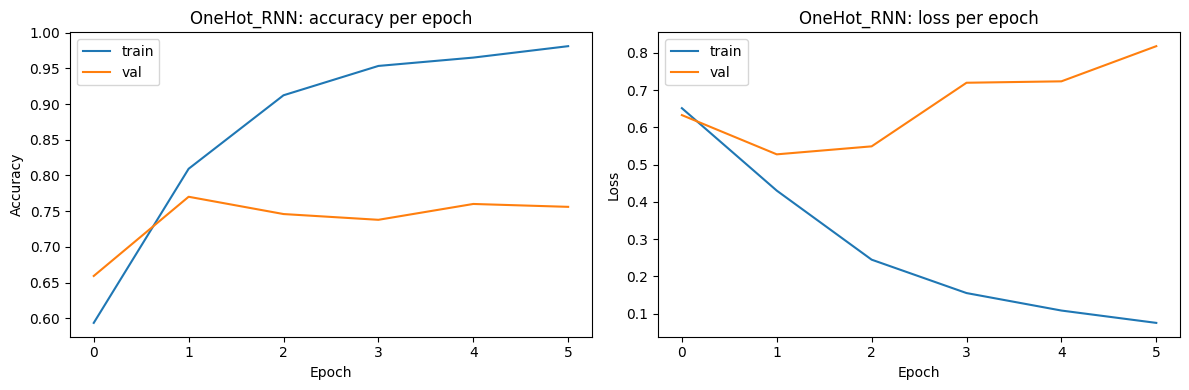

[0.0398234  0.92582166 0.93629366 0.4294763  0.05930419 0.70110714
 0.0376551  0.76955765 0.9622173  0.11943791 0.11533783 0.96413577
 0.94446045 0.12348446 0.06133498 0.3565056  0.82551503 0.5338433
 0.9396718  0.8328439 ]
min: 0.030058408
max: 0.97212684
mean: 0.5519526
  Accuracy=0.7560  F1=0.7704  Precision=0.7382  Recall=0.8056


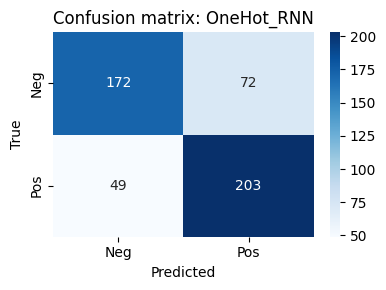

              precision    recall  f1-score   support

    Negative       0.78      0.70      0.74       244
    Positive       0.74      0.81      0.77       252

    accuracy                           0.76       496
   macro avg       0.76      0.76      0.76       496
weighted avg       0.76      0.76      0.76       496



In [37]:
# OneHot + SimpleRNN
best_oh = all_search_results["OneHot_RNN"].iloc[0]
hd_oh = int(best_oh["hidden_dim"])
dr_oh = float(best_oh["dropout"])
bs_oh = int(best_oh["batch_size"])
print(f"OneHot_RNN — best: hidden={hd_oh}, dropout={dr_oh}, batch={bs_oh}")

model_oh_rnn = build_oh_rnn(hidden_dim=hd_oh, dropout=dr_oh)
hist_oh_rnn = model_oh_rnn.fit(
    X_train_oh, y_train,
    validation_data=(X_val_oh, y_val),
    epochs=EPOCHS, batch_size=bs_oh,
    callbacks=get_callbacks("OneHot_RNN"),
    class_weight=CLASS_WEIGHTS, verbose=1)
plot_history(hist_oh_rnn, "OneHot_RNN")
y_pred_oh_rnn = evaluate_keras(model_oh_rnn, X_test_oh, y_test, "OneHot_RNN", hist_oh_rnn)
plot_confusion(y_test, y_pred_oh_rnn, "OneHot_RNN")
print(classification_report(y_test, y_pred_oh_rnn, target_names=["Negative", "Positive"]))



Final training: Embed_RNN
  embed_dim=64  hidden_dim=128  dropout=0.4  batch_size=32
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.5473 - loss: 0.6921 - val_accuracy: 0.5706 - val_loss: 0.6846 - learning_rate: 0.0010
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8232 - loss: 0.4885 - val_accuracy: 0.6774 - val_loss: 0.6244 - learning_rate: 0.0010
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9313 - loss: 0.2354 - val_accuracy: 0.7440 - val_loss: 0.7021 - learning_rate: 0.0010
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9719 - loss: 0.1079 - val_accuracy: 0.7560 - val_loss: 0.9104 - learning_rate: 0.0010
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9792 - loss: 0.0816 - val_accuracy: 0.7722 - val_loss: 0.7056 - learning_rate: 5.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9939 - loss: 0.0389 - val_accuracy: 0.7621 - val_loss: 0.6955 - learning_rate: 5.0000e-04


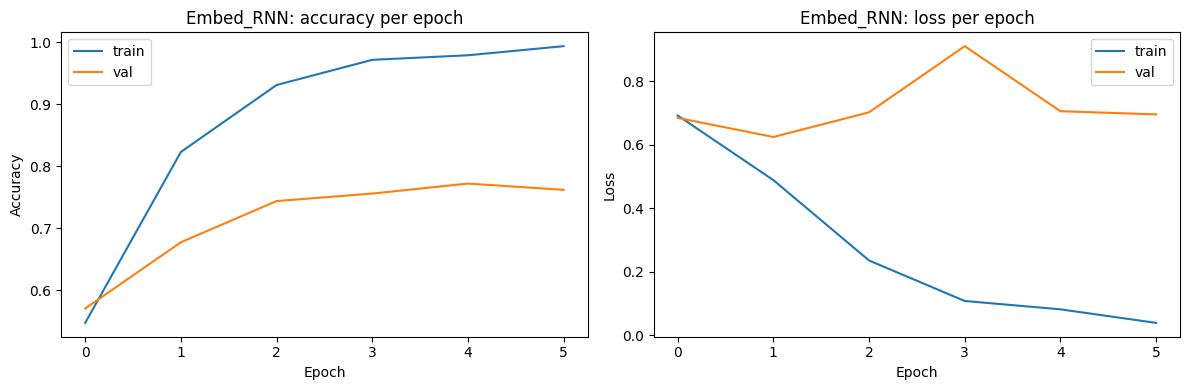

[0.34620598 0.80040175 0.55000156 0.60219944 0.4121561  0.833295
 0.43850973 0.74254787 0.92959803 0.14673156 0.5053945  0.6534125
 0.25102848 0.38990524 0.55631435 0.7906026  0.5963539  0.9827109
 0.6793834  0.65906626]
min: 0.009337633
max: 0.9931206
mean: 0.5017098
  Accuracy=0.6754  F1=0.6824  Precision=0.6784  Recall=0.6865


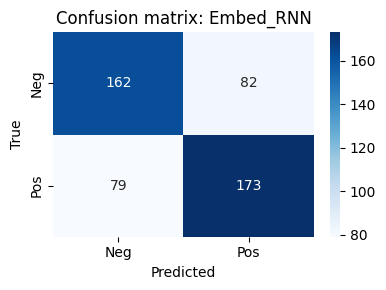

              precision    recall  f1-score   support

    Negative       0.67      0.66      0.67       244
    Positive       0.68      0.69      0.68       252

    accuracy                           0.68       496
   macro avg       0.68      0.68      0.68       496
weighted avg       0.68      0.68      0.68       496



In [38]:
model_emb_rnn, hist_emb_rnn, y_pred_emb_rnn = train_best(
    "Embed_RNN", build_embed_rnn,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["Embed_RNN"])



Final training: GRU
  embed_dim=64  hidden_dim=128  dropout=0.4  batch_size=32
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.6118 - loss: 0.6650 - val_accuracy: 0.7137 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.8764 - loss: 0.3412 - val_accuracy: 0.8347 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9555 - loss: 0.1427 - val_accuracy: 0.8226 - val_loss: 0.7463 - learning_rate: 0.0010
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9797 - loss: 0.0667 - val_accuracy: 0.8024 - val_loss: 0.9538 - learning_rate: 0.0010
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9922 - loss: 0.0334 - val_accuracy: 0.8185 - val_loss: 0.7262 - learning_rate: 5.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9961 - loss: 0.0206 - val_accuracy: 0.8145 - val_loss: 0.7947 - learning_rate: 5.0000e-04
Epoch

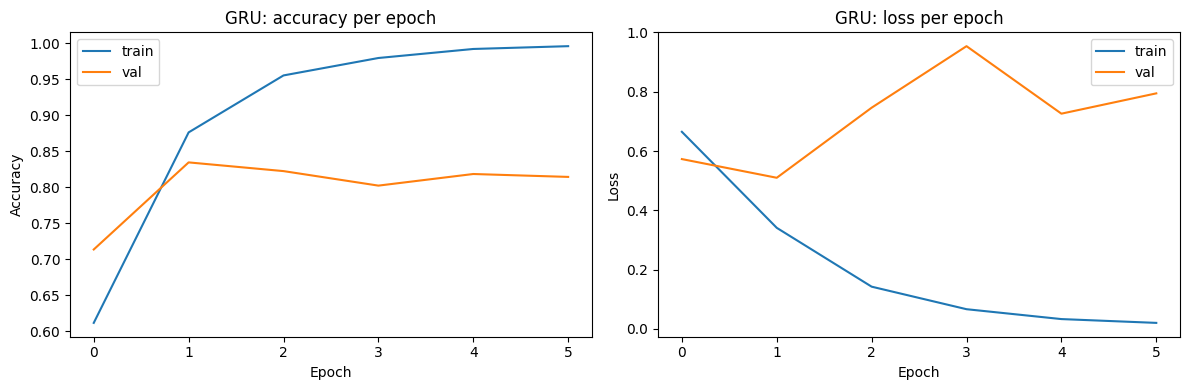

[0.00459429 0.999954   0.91717666 0.98380005 0.11336002 0.62633353
 0.04633129 0.27269658 0.99960774 0.01882337 0.08204345 0.9654435
 0.98934865 0.01999633 0.6455097  0.99508035 0.8119753  0.9884715
 0.95151246 0.23652756]
min: 0.00036751194
max: 1.0
mean: 0.5113842
  Accuracy=0.7984  F1=0.7984  Precision=0.8115  Recall=0.7857


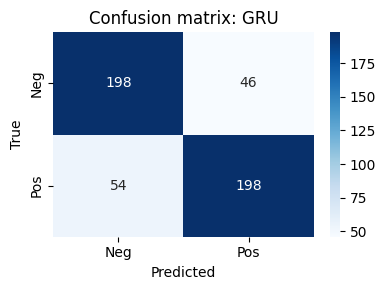

              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80       244
    Positive       0.81      0.79      0.80       252

    accuracy                           0.80       496
   macro avg       0.80      0.80      0.80       496
weighted avg       0.80      0.80      0.80       496



In [39]:
model_gru, hist_gru, y_pred_gru = train_best(
    "GRU", build_gru,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["GRU"])



Final training: LSTM
  embed_dim=128  hidden_dim=64  dropout=0.4  batch_size=32
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.5283 - loss: 0.6915 - val_accuracy: 0.6210 - val_loss: 0.6886 - learning_rate: 3.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6814 - loss: 0.6667 - val_accuracy: 0.7319 - val_loss: 0.6287 - learning_rate: 3.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8513 - loss: 0.4904 - val_accuracy: 0.7802 - val_loss: 0.5583 - learning_rate: 3.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9308 - loss: 0.2869 - val_accuracy: 0.8024 - val_loss: 0.6007 - learning_rate: 3.0000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9637 - loss: 0.1605 - val_accuracy: 0.8105 - val_loss: 0.7863 - learning_rate: 3.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9810 - loss: 0.1085 - val_accuracy: 0.8085 - val_loss: 0.9215 - learning_rate: 

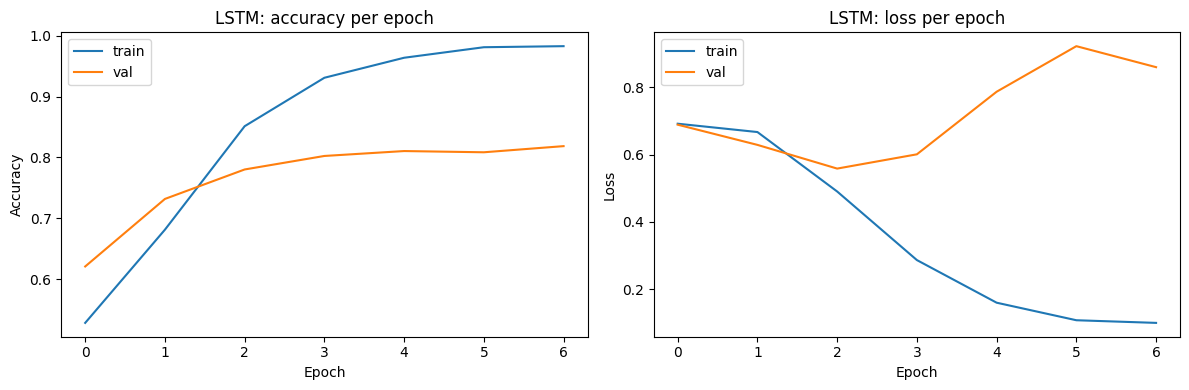

[0.19568782 0.93024945 0.59429276 0.22875813 0.3950736  0.55538845
 0.37590125 0.7639874  0.8440456  0.09567504 0.2862083  0.6442655
 0.77130866 0.3478132  0.2714472  0.7178144  0.8152296  0.8985647
 0.6330861  0.43277836]
min: 0.013774205
max: 0.9974311
mean: 0.506753
  Accuracy=0.7823  F1=0.7840  Precision=0.7903  Recall=0.7778


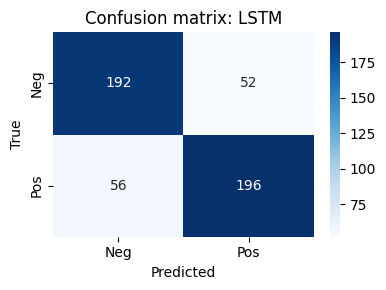

              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78       244
    Positive       0.79      0.78      0.78       252

    accuracy                           0.78       496
   macro avg       0.78      0.78      0.78       496
weighted avg       0.78      0.78      0.78       496



In [40]:
model_lstm, hist_lstm, y_pred_lstm = train_best(
    "LSTM", build_lstm,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["LSTM"])



Final training: BiLSTM
  embed_dim=64  hidden_dim=64  dropout=0.4  batch_size=64
Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.4959 - loss: 0.6930 - val_accuracy: 0.5060 - val_loss: 0.6923 - learning_rate: 3.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.5326 - loss: 0.6904 - val_accuracy: 0.5827 - val_loss: 0.6887 - learning_rate: 3.0000e-04
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.6269 - loss: 0.6781 - val_accuracy: 0.6915 - val_loss: 0.6645 - learning_rate: 3.0000e-04
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.7354 - loss: 0.6082 - val_accuracy: 0.7621 - val_loss: 0.5816 - learning_rate: 3.0000e-04
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.8435 - loss: 0.4298 - val_accuracy: 0.7944 - val_loss: 0.4786 - learning_rate: 3.0000e-04
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.9209 - loss: 0.2450 - val_accuracy: 0.8306 - val_loss: 0.4412 - learnin

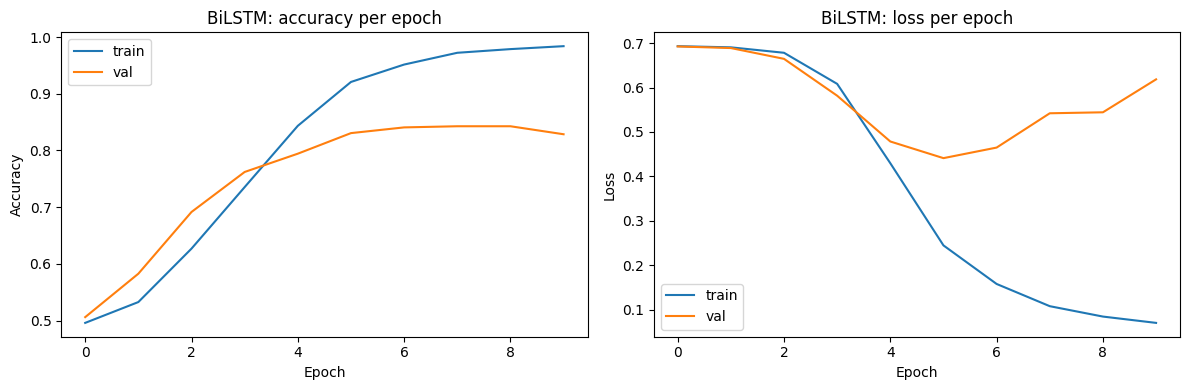

[0.04497262 0.9887382  0.89815533 0.83948725 0.42439565 0.5128944
 0.10766453 0.96933234 0.9633428  0.02078793 0.2539956  0.79230636
 0.896054   0.08766935 0.08709496 0.9749067  0.8192376  0.90779305
 0.81295305 0.43657032]
min: 0.003544733
max: 0.9994475
mean: 0.5354157
  Accuracy=0.7923  F1=0.8008  Precision=0.7811  Recall=0.8214


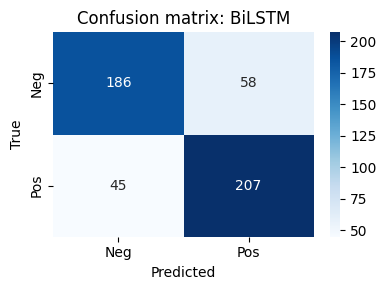

              precision    recall  f1-score   support

    Negative       0.81      0.76      0.78       244
    Positive       0.78      0.82      0.80       252

    accuracy                           0.79       496
   macro avg       0.79      0.79      0.79       496
weighted avg       0.79      0.79      0.79       496



In [41]:
model_bilstm, hist_bilstm, y_pred_bilstm = train_best(
    "BiLSTM", build_bilstm,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["BiLSTM"])



Final training: Conv1D
  embed_dim=128  hidden_dim=64  dropout=0.2  batch_size=32
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5594 - loss: 0.6841 - val_accuracy: 0.6935 - val_loss: 0.6447 - learning_rate: 0.0010
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8029 - loss: 0.4436 - val_accuracy: 0.8206 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9455 - loss: 0.1524 - val_accuracy: 0.7964 - val_loss: 0.5572 - learning_rate: 0.0010
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9844 - loss: 0.0538 - val_accuracy: 0.8065 - val_loss: 0.6130 - learning_rate: 0.0010
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9970 - loss: 0.0186 - val_accuracy: 0.8085 - val_loss: 0.6457 - learning_rate: 5.0000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9983 - loss: 0.0117 - val_accuracy: 0.8105 - val_loss: 0.7024 - learning_rate: 5.0000e-04
Epo

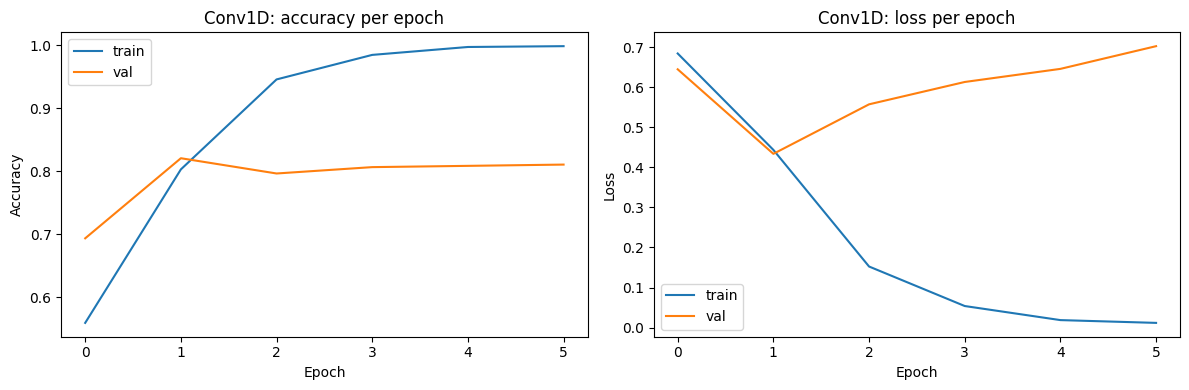

[0.0757439  0.9952095  0.9847829  0.72558504 0.47753522 0.7644213
 0.03986657 0.9193934  0.9791542  0.01063538 0.24577029 0.9480243
 0.60430884 0.01952466 0.46877947 0.9774451  0.7035265  0.75086135
 0.91244143 0.38942727]
min: 0.0003871623
max: 0.99978024
mean: 0.52450573
  Accuracy=0.7923  F1=0.7960  Precision=0.7945  Recall=0.7976


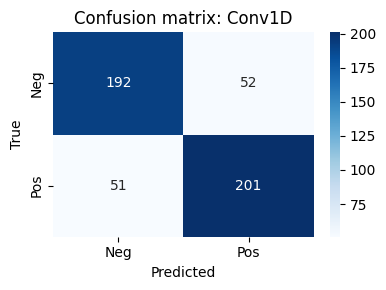

              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79       244
    Positive       0.79      0.80      0.80       252

    accuracy                           0.79       496
   macro avg       0.79      0.79      0.79       496
weighted avg       0.79      0.79      0.79       496



In [42]:
model_conv, hist_conv, y_pred_conv = train_best(
    "Conv1D", build_conv1d,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["Conv1D"])



Final training: Conv1D_LSTM
  embed_dim=128  hidden_dim=128  dropout=0.4  batch_size=32
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.5002 - loss: 0.6939 - val_accuracy: 0.5081 - val_loss: 0.6930 - learning_rate: 3.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5006 - loss: 0.6941 - val_accuracy: 0.5081 - val_loss: 0.6930 - learning_rate: 3.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4834 - loss: 0.6934 - val_accuracy: 0.5081 - val_loss: 0.6931 - learning_rate: 3.0000e-04
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.4691 - loss: 0.6932 - val_accuracy: 0.4919 - val_loss: 0.6931 - learning_rate: 1.5000e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.4937 - loss: 0.6931 - val_accuracy: 0.4919 - val_loss: 0.6932 - learning_rate: 1.5000e-04
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4998 - loss: 0.6931 - val_accuracy: 0.5081 - val_loss: 0.6931 - learni

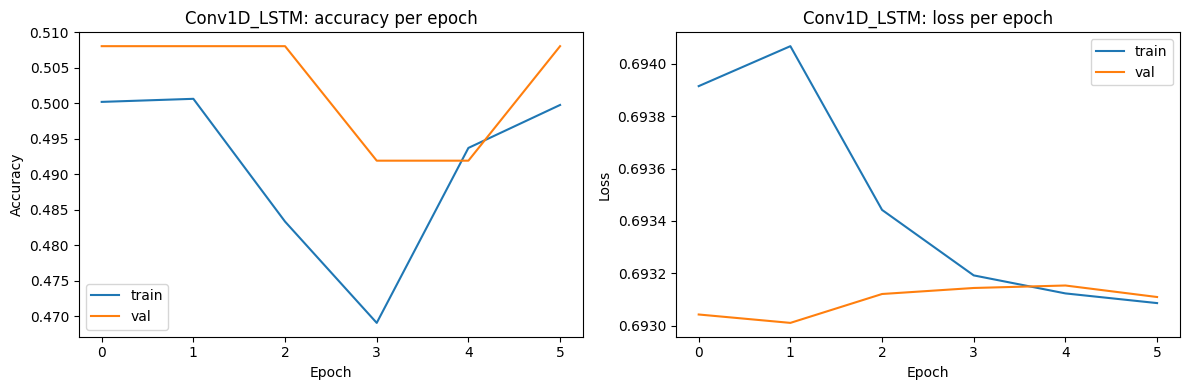

[0.50736386 0.507379   0.50736696 0.5073755  0.5073681  0.5073622
 0.50736445 0.5073728  0.5073685  0.5073458  0.50736946 0.50737065
 0.50737274 0.5073638  0.5073562  0.5073685  0.507326   0.50737256
 0.5073645  0.50736624]
min: 0.5071062
max: 0.5074062
mean: 0.5073594
  Accuracy=0.5081  F1=0.6738  Precision=0.5081  Recall=1.0000


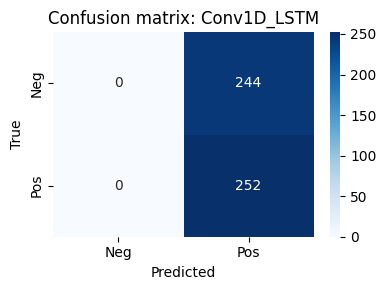

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       244
    Positive       0.51      1.00      0.67       252

    accuracy                           0.51       496
   macro avg       0.25      0.50      0.34       496
weighted avg       0.26      0.51      0.34       496



In [43]:
model_conv_lstm, hist_conv_lstm, y_pred_conv_lstm = train_best(
    "Conv1D_LSTM", build_conv_lstm,
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    all_search_results["Conv1D_LSTM"])


**Wniosek — przeszukiwanie hiperparametrów:**  
Heatmapy embed_dim × hidden_dim i dropout × batch_size pokazują wyraźne wzorce:  
większe embeddingi pomagają GRU/LSTM, Conv1D preferuje mniejszy dropout.


## 9. Dostrajanie DistilBERT (Transformer)

DistilBERT to destylowana wersja BERT: 40% mniejsza, 60% szybsza, zachowująca ~97%  
wydajności BERT. Dostrajamy jedynie głowicę klasyfikacyjną przez 3 epoki, używając  
HuggingFace Transformers + PyTorch Trainer API.  
Punkty kontrolne są zapisywane po każdej epoce przez `save_strategy="epoch"`.


In [44]:
import torch
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments)
from datasets import Dataset
import evaluate
import datasets
datasets.disable_caching()
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


PyTorch version: 2.7.0+cu128
CUDA available: True
Device: cuda


In [45]:
BERT_MODEL   = "distilbert-base-uncased"
BERT_MAX_LEN = 128

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

def tokenize_bert(batch):
    return tokenizer_bert(batch["text"], truncation=True, padding="max_length", max_length=BERT_MAX_LEN)

# Build HuggingFace datasets
def make_hf_dataset(texts, labels):
    d = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    d = d.map(tokenize_bert, batched=True, batch_size=128)
    d.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    return d

hf_train = make_hf_dataset(X_train, y_train)
hf_val   = make_hf_dataset(X_val,   y_val)
hf_test  = make_hf_dataset(X_test,  y_test)

print("HF datasets ready")
print("Train:", len(hf_train), " Val:", len(hf_val), " Test:", len(hf_test))


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 496/496 [00:00<00:00, 11431.01 examples/s]

HF datasets ready
Train: 2313  Val: 496  Test: 496


In [46]:
hf_train.features

{'text': Value(dtype='string', id=None),
 'label': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [47]:
hf_train.set_format("torch")
hf_val.set_format("torch")

In [48]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
)
print(f"DistilBERT parameters: {sum(p.numel() for p in bert_model.parameters()):,}")


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1524.61it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT parameters: 66,955,010


In [49]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels)["f1"]
    return {"accuracy": acc, "f1": f1}


In [51]:
BERT_OUTPUT_DIR = os.path.join(CHECKPOINT_DIR, "distilbert")
os.makedirs(BERT_OUTPUT_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=BERT_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    fp16=True,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=21,
    eval_strategy="epoch", 
    save_strategy="epoch", 
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

print("Training args ready. Checkpoints saved to:", BERT_OUTPUT_DIR)


Training args ready. Checkpoints saved to: results/checkpoints/distilbert


In [52]:
print("Fine-tuning DistilBERT...")
start = time.time()
trainer.train()
elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")


Fine-tuning DistilBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.093403,0.240493,0.907258,0.907631
2,0.509067,0.203558,0.921371,0.923379
3,0.262143,0.207538,0.923387,0.924603


Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.96it/s]


Training finished in 0.9 minutes


In [53]:
# Evaluate on test set
bert_preds = trainer.predict(hf_test)
bert_logits = bert_preds.predictions
y_pred_bert = np.argmax(bert_logits, axis=1)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
bert_acc  = accuracy_score(y_test, y_pred_bert)
bert_f1   = f1_score(y_test, y_pred_bert)
bert_prec = precision_score(y_test, y_pred_bert)
bert_rec  = recall_score(y_test, y_pred_bert)

results["DistilBERT"] = {
    "accuracy": bert_acc, "f1": bert_f1,
    "precision": bert_prec, "recall": bert_rec
}

print(f"DistilBERT Test  Accuracy={bert_acc:.4f}  F1={bert_f1:.4f}  "
      f"Precision={bert_prec:.4f}  Recall={bert_rec:.4f}")
print()
print(classification_report(y_test, y_pred_bert, target_names=["Negative", "Positive"]))


DistilBERT Test  Accuracy=0.9153  F1=0.9160  Precision=0.9234  Recall=0.9087

              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91       244
    Positive       0.92      0.91      0.92       252

    accuracy                           0.92       496
   macro avg       0.92      0.92      0.92       496
weighted avg       0.92      0.92      0.92       496



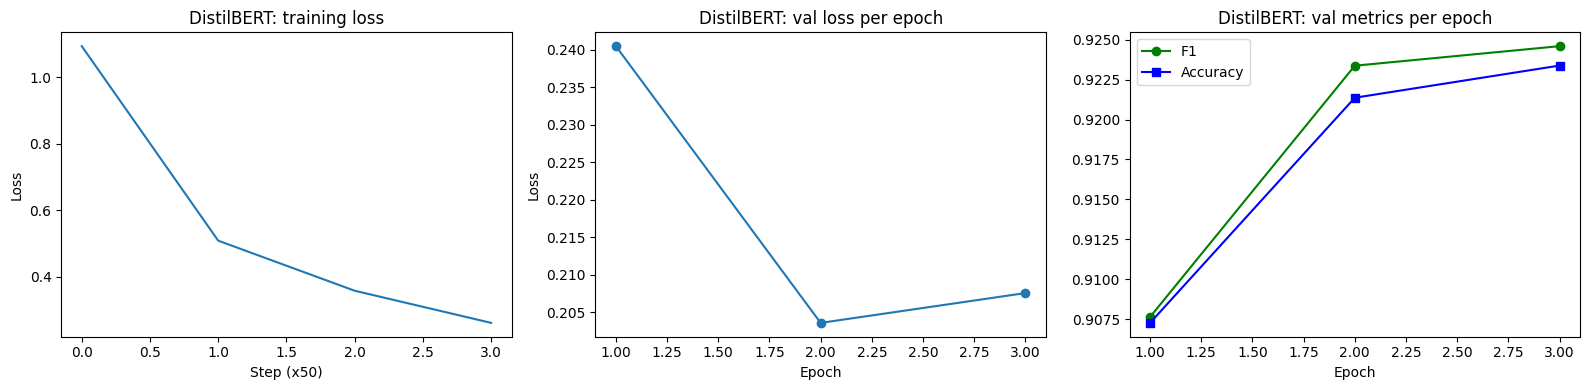

In [54]:
# Training history from log_history
log = trainer.state.log_history
train_loss = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
eval_loss  = [x["eval_loss"] for x in log if "eval_loss" in x]
eval_acc   = [x["eval_accuracy"] for x in log if "eval_accuracy" in x]
eval_f1    = [x["eval_f1"]       for x in log if "eval_f1"       in x]

epochs_range = range(1, len(eval_loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_loss, label="train loss")
axes[0].set_title("DistilBERT: training loss")
axes[0].set_xlabel("Step (x50)")
axes[0].set_ylabel("Loss")

axes[1].plot(epochs_range, eval_loss, marker="o")
axes[1].set_title("DistilBERT: val loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

axes[2].plot(epochs_range, eval_f1, marker="o", color="green", label="F1")
axes[2].plot(epochs_range, eval_acc, marker="s", color="blue",  label="Accuracy")
axes[2].set_title("DistilBERT: val metrics per epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "history_DistilBERT.png"), dpi=100, bbox_inches="tight")
plt.show()


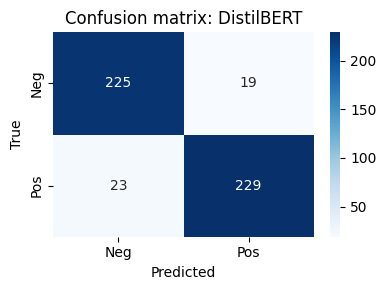

In [55]:
plot_confusion(y_test, y_pred_bert, "DistilBERT")

**Wniosek (DistilBERT):**  
Dostrajanie wymaga zaledwie 3 epok i zazwyczaj daje znacząco wyższą dokładność niż  
modele rekurencyjne trenowane od zera, szczególnie dla zadań wymagających rozumienia negacji,  
ironii i zależności od kolejności słów.  


### Analiza błędnych klasyfikacji — DistilBERT

Poniżej prezentujemy przykłady próbek, które model **błędnie** sklasyfikował.  
Analiza pomyłek pozwala zrozumieć, z jakimi wzorcami językowymi model ma największe trudności.


In [56]:
import pandas as pd
from IPython.display import display, HTML

label_names = {0: "Negatywny", 1: "Pozytywny"}

misclassified_mask = y_pred_bert != y_test
mis_indices = np.where(misclassified_mask)[0]

mis_neg_as_pos = mis_indices[y_test[mis_indices] == 0][:15]  # Negatywny -> Pozytywny
mis_pos_as_neg = mis_indices[y_test[mis_indices] == 1][:15]  # Pozytywny -> Negatywny

rows = []
for idx in mis_neg_as_pos:
    rows.append({
        "Tekst": X_test[idx],
        "Prawdziwa etykieta": label_names[int(y_test[idx])],
        "Predykcja modelu": label_names[int(y_pred_bert[idx])],
        "Typ błędu": "Fałszywy pozytywny (FP)"
    })
for idx in mis_pos_as_neg:
    rows.append({
        "Tekst": X_test[idx],
        "Prawdziwa etykieta": label_names[int(y_test[idx])],
        "Predykcja modelu": label_names[int(y_pred_bert[idx])],
        "Typ błędu": "Fałszywy negatywny (FN)"
    })

mis_df = pd.DataFrame(rows)

def color_error_type(val):
    if "Fałszywy pozytywny" in val:
        return "background-color: #fdd; color: #900"
    elif "Fałszywy negatywny" in val:
        return "background-color: #ddf; color: #009"
    return ""

styled = (
    mis_df.style
    .applymap(color_error_type, subset=["Typ błędu"])
    .set_properties(**{"text-align": "left", "font-size": "12px"})
    .set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#4472C4"), ("color", "white"),
                  ("font-size", "13px"), ("text-align", "left")]
    }])
    .set_caption(f"Tabela błędnych klasyfikacji DistilBERT "
                 f"(łącznie błędów: {misclassified_mask.sum()}, "
                 f"pokazano: {len(mis_df)})")
    .hide(axis="index")
)

print(f"Łączna liczba błędnych klasyfikacji: {misclassified_mask.sum()} "
      f"/ {len(y_test)} ({100*misclassified_mask.mean():.1f}%)")
print(f"  Fałszywe pozytywy (neg→pos): {len(mis_neg_as_pos)}")
print(f"  Fałszywe negatywy (pos→neg): {len(mis_pos_as_neg)}")
print()
display(styled)


Łączna liczba błędnych klasyfikacji: 42 / 496 (8.5%)
  Fałszywe pozytywy (neg→pos): 15
  Fałszywe negatywy (pos→neg): 15



Tekst,Prawdziwa etykieta,Predykcja modelu,Typ błędu
"for 40 bucks a head, i really expect better food.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"characters are one dimensional, even the good guys and especially the bad guys.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
it was packed!!,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
sports organizations must do more to address issues of corruption and integrity.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"if you look for authentic thai food, go else where.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"seems like a good quick place to grab a bite of some familiar pub food, but do yourself a favor and look elsewhere.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"and, finally, after all that, we get to an ending that would've been great had it been handled by competent people and not jerry falwell.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
the use of leverage in financial markets amplifies both gains and losses for investors.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
the commercialization of sports has led to the commodification of athletes.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
this allows the possibility of double booking for the same date and time after the first.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)


## 10. Dostrajanie DistilRoBERTa (Transformer — alternatywa)

**DistilRoBERTa** (`distilroberta-base`) to destylowana wersja RoBERTy — ulepszonego BERT-a  
trenowanego na większych danych.  

Używamy identycznego pipeline'u jak dla DistilBERT, aby wyniki były w pełni porównywalne.


In [57]:
import torch
from transformers import (RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments)
from datasets import Dataset
import evaluate

ROBERTA_MODEL   = "distilroberta-base"
ROBERTA_MAX_LEN = 128

tokenizer_roberta = RobertaTokenizerFast.from_pretrained(ROBERTA_MODEL)

def tokenize_roberta(batch):
    return tokenizer_roberta(batch["text"],
                              truncation=True,
                              padding="max_length",
                              max_length=ROBERTA_MAX_LEN)

def make_hf_roberta(texts, labels):
    d = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    d = d.map(tokenize_roberta, batched=True, batch_size=128)
    d.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    return d

hf_train_rob = make_hf_roberta(X_train, y_train)
hf_val_rob   = make_hf_roberta(X_val,   y_val)
hf_test_rob  = make_hf_roberta(X_test,  y_test)

print("HF datasets (RoBERTa) gotowe")
print("Train:", len(hf_train_rob), " Val:", len(hf_val_rob), " Test:", len(hf_test_rob))


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 496/496 [00:00<00:00, 11912.70 examples/s]

HF datasets (RoBERTa) gotowe
Train: 2313  Val: 496  Test: 496


In [58]:
roberta_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL, num_labels=2
)
print(f"DistilRoBERTa parametry: {sum(p.numel() for p in roberta_model.parameters()):,}")


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 1610.94it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MI

DistilRoBERTa parametry: 82,119,938


In [60]:
ROBERTA_OUTPUT_DIR = os.path.join(CHECKPOINT_DIR, "distilroberta")
os.makedirs(ROBERTA_OUTPUT_DIR, exist_ok=True)

roberta_training_args = TrainingArguments(
    output_dir=ROBERTA_OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=21,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=hf_train_rob,
    eval_dataset=hf_val_rob,
    compute_metrics=compute_metrics,
)
print("Trainer DistilRoBERTa gotowy. Checkpointy:", ROBERTA_OUTPUT_DIR)


Trainer DistilRoBERTa gotowy. Checkpointy: results/checkpoints/distilroberta


In [61]:
print("Fine-tuning DistilRoBERTa...")
start = time.time()
roberta_trainer.train()
elapsed_rob = time.time() - start
print(f"Trening zakończony w {elapsed_rob/60:.1f} minut")


Fine-tuning DistilRoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.601916,0.324924,0.870968,0.885714
2,0.256707,0.181776,0.935484,0.938931
3,0.138445,0.186261,0.939516,0.941406


Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.80it/s]


Trening zakończony w 0.6 minut


In [62]:
# Ewaluacja na zbiorze testowym
rob_preds    = roberta_trainer.predict(hf_test_rob)
rob_logits   = rob_preds.predictions
y_pred_rob   = np.argmax(rob_logits, axis=1)

rob_acc  = accuracy_score(y_test, y_pred_rob)
rob_f1   = f1_score(y_test, y_pred_rob)
rob_prec = precision_score(y_test, y_pred_rob)
rob_rec  = recall_score(y_test, y_pred_rob)

results["DistilRoBERTa"] = {
    "accuracy":  rob_acc, "f1": rob_f1,
    "precision": rob_prec, "recall": rob_rec
}

print(f"DistilRoBERTa  Accuracy={rob_acc:.4f}  F1={rob_f1:.4f}  "
      f"Precision={rob_prec:.4f}  Recall={rob_rec:.4f}")
print()
print(classification_report(y_test, y_pred_rob, target_names=["Negative", "Positive"]))


DistilRoBERTa  Accuracy=0.9274  F1=0.9291  Precision=0.9219  Recall=0.9365

              precision    recall  f1-score   support

    Negative       0.93      0.92      0.93       244
    Positive       0.92      0.94      0.93       252

    accuracy                           0.93       496
   macro avg       0.93      0.93      0.93       496
weighted avg       0.93      0.93      0.93       496



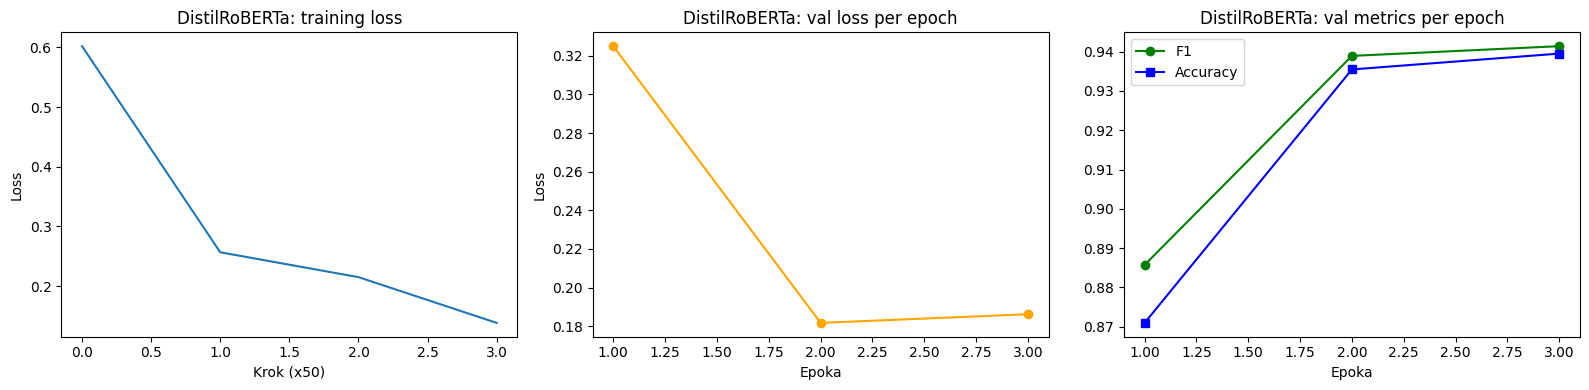

In [63]:
# Historia trenowania DistilRoBERTa
log_rob   = roberta_trainer.state.log_history
tr_loss_r = [x["loss"]         for x in log_rob if "loss" in x and "eval_loss" not in x]
ev_loss_r = [x["eval_loss"]    for x in log_rob if "eval_loss" in x]
ev_acc_r  = [x["eval_accuracy"] for x in log_rob if "eval_accuracy" in x]
ev_f1_r   = [x["eval_f1"]      for x in log_rob if "eval_f1" in x]
ep_range_r = range(1, len(ev_loss_r) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(tr_loss_r, label="train loss")
axes[0].set_title("DistilRoBERTa: training loss")
axes[0].set_xlabel("Krok (x50)"); axes[0].set_ylabel("Loss")

axes[1].plot(ep_range_r, ev_loss_r, marker="o", color="orange")
axes[1].set_title("DistilRoBERTa: val loss per epoch")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Loss")

axes[2].plot(ep_range_r, ev_f1_r,  marker="o", color="green",  label="F1")
axes[2].plot(ep_range_r, ev_acc_r, marker="s", color="blue",   label="Accuracy")
axes[2].set_title("DistilRoBERTa: val metrics per epoch")
axes[2].set_xlabel("Epoka"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "history_DistilRoBERTa.png"), dpi=100, bbox_inches="tight")
plt.show()


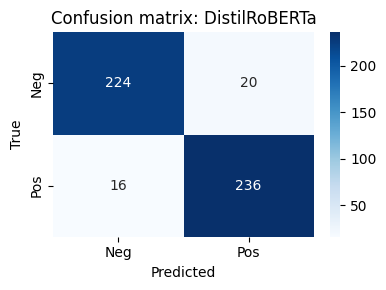

In [64]:
plot_confusion(y_test, y_pred_rob, "DistilRoBERTa")

### Bezpośrednie porównanie: DistilBERT vs DistilRoBERTa


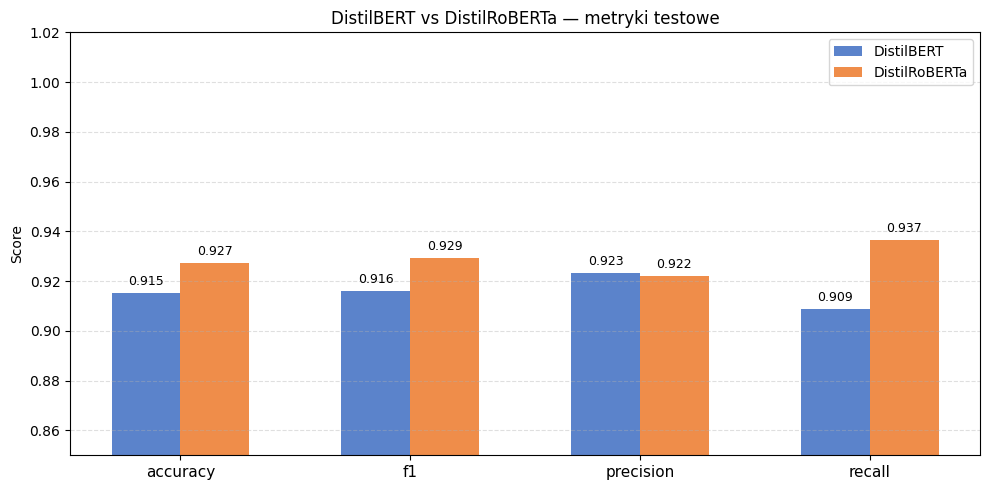

In [65]:
# Porównanie Transformer models
transformer_names = ["DistilBERT", "DistilRoBERTa"]
tr_metrics = ["accuracy", "f1", "precision", "recall"]
tr_vals = {m: [results[m][k] for k in tr_metrics] for m in transformer_names}

x_tr = np.arange(len(tr_metrics))
width_tr = 0.3
fig, ax = plt.subplots(figsize=(10, 5))
colors_tr = ["#4472C4", "#ED7D31"]
for i, (name, col) in enumerate(zip(transformer_names, colors_tr)):
    ax.bar(x_tr + i * width_tr, tr_vals[name], width_tr, label=name, color=col, alpha=0.88)
    
ax.set_xticks(x_tr + width_tr / 2)
ax.set_xticklabels(tr_metrics, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score")
ax.set_title("DistilBERT vs DistilRoBERTa — metryki testowe")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
for i, (name, col) in enumerate(zip(transformer_names, colors_tr)):
    for j, val in enumerate(tr_vals[name]):
        ax.text(x_tr[j] + i * width_tr, val + 0.002, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "transformer_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()


In [66]:
# Błędne klasyfikacje DistilRoBERTa
label_names = {0: "Negatywny", 1: "Pozytywny"}
mis_mask_rob = y_pred_rob != y_test
mis_idx_rob  = np.where(mis_mask_rob)[0]
mis_neg_rob  = mis_idx_rob[y_test[mis_idx_rob] == 0][:15]
mis_pos_rob  = mis_idx_rob[y_test[mis_idx_rob] == 1][:15]

rows_rob = []
for idx in mis_neg_rob:
    rows_rob.append({"Tekst": X_test[idx],
                     "Prawdziwa etykieta": label_names[int(y_test[idx])],
                     "Predykcja": label_names[int(y_pred_rob[idx])],
                     "Typ błędu": "Fałszywy pozytywny (FP)"})
for idx in mis_pos_rob:
    rows_rob.append({"Tekst": X_test[idx],
                     "Prawdziwa etykieta": label_names[int(y_test[idx])],
                     "Predykcja": label_names[int(y_pred_rob[idx])],
                     "Typ błędu": "Fałszywy negatywny (FN)"})

mis_rob_df = pd.DataFrame(rows_rob)
print(f"DistilRoBERTa — błędnych klasyfikacji: {mis_mask_rob.sum()}/{len(y_test)} "
      f"({100*mis_mask_rob.mean():.1f}%)")
display(mis_rob_df.style.applymap(
    lambda v: "background-color:#fdd;color:#900" if "pozytywny" in v else
              "background-color:#ddf;color:#009" if "negatywny" in v else "",
    subset=["Typ błędu"]).hide(axis="index"))


DistilRoBERTa — błędnych klasyfikacji: 36/496 (7.3%)


Tekst,Prawdziwa etykieta,Predykcja,Typ błędu
a lady at the table next to us found a live green caterpillar in her salad.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"characters are one dimensional, even the good guys and especially the bad guys.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
it was packed!!,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
i ordered this for sony ericsson w810i but i think it only worked once thats when i first used it .,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"if you look for authentic thai food, go else where.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"seems like a good quick place to grab a bite of some familiar pub food, but do yourself a favor and look elsewhere.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
"and, finally, after all that, we get to an ending that would've been great had it been handled by competent people and not jerry falwell.",Negatywny,Pozytywny,Fałszywy pozytywny (FP)
the use of leverage in financial markets amplifies both gains and losses for investors.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
this allows the possibility of double booking for the same date and time after the first.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)
it also took her forever to bring us the check when we asked for it.,Negatywny,Pozytywny,Fałszywy pozytywny (FP)


## 11. Finalne porównanie wszystkich modeli (finalne (po przeszukiwaniu hiperparametrów))

In [67]:
# Pełna tabela porównawcza — bazowe + tuned + Transformery
comp_df_full = pd.DataFrame([
    {"Model": k,
     "Accuracy":  v["accuracy"],
     "F1":        v["f1"],
     "Precision": v["precision"],
     "Recall":    v["recall"]}
    for k, v in results.items()
]).sort_values("F1", ascending=False).reset_index(drop=True)

print("Pełne porównanie modeli:")
print(comp_df_full.to_string(index=False))


Pełne porównanie modeli:
        Model  Accuracy       F1  Precision   Recall
DistilRoBERTa  0.927419 0.929134   0.921875 0.936508
   DistilBERT  0.915323 0.916000   0.923387 0.908730
       BiLSTM  0.792339 0.800774   0.781132 0.821429
          GRU  0.798387 0.798387   0.811475 0.785714
       Conv1D  0.792339 0.796040   0.794466 0.797619
         LSTM  0.782258 0.784000   0.790323 0.777778
   OneHot_RNN  0.756048 0.770398   0.738182 0.805556
    Embed_RNN  0.675403 0.682446   0.678431 0.686508
  Conv1D_LSTM  0.508065 0.673797   0.508065 1.000000


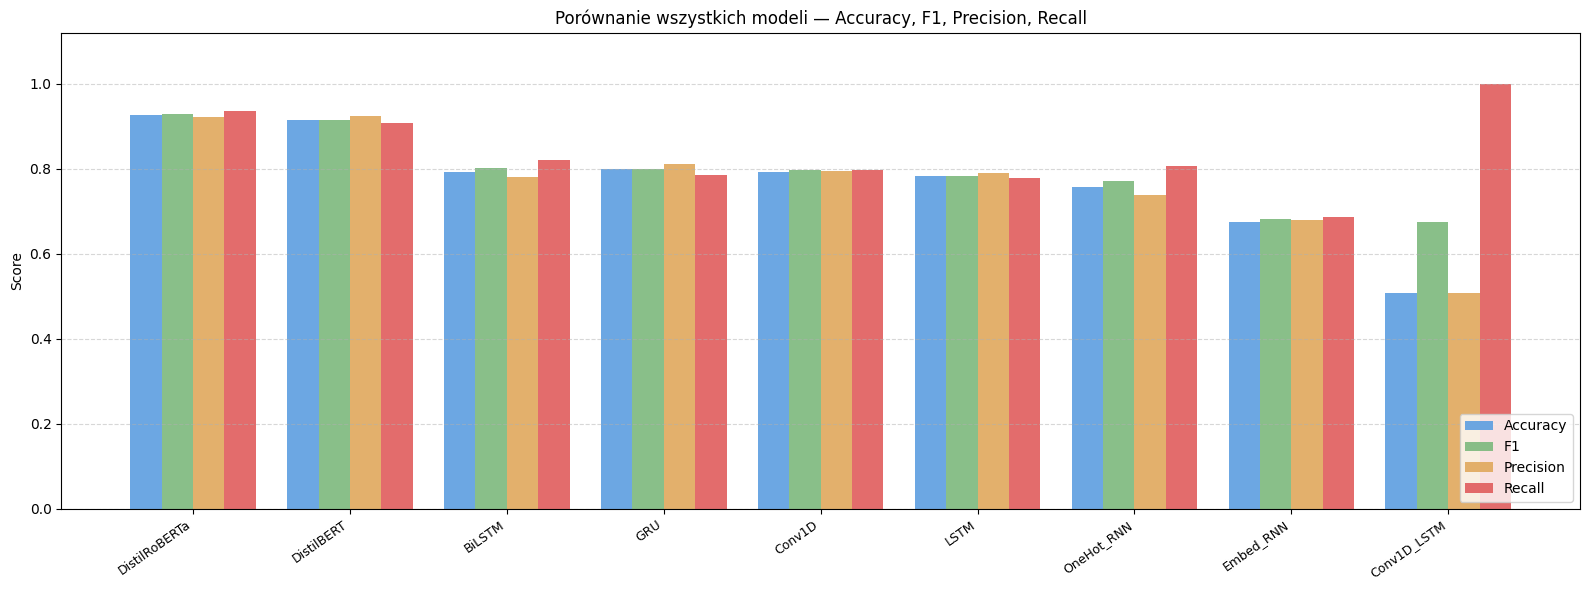

In [68]:
# ---- Grouped bar chart: finalne modele (po grid search) ----
metrics_plot = ["Accuracy", "F1", "Precision", "Recall"]
x_full = np.arange(len(comp_df_full))
width_full = 0.2
colors_full = ["#5c9ee0", "#7cb87c", "#e0a85c", "#e05c5c"]

fig, ax = plt.subplots(figsize=(max(16, len(comp_df_full)*1.4), 6))
for i, (metric, color) in enumerate(zip(metrics_plot, colors_full)):
    ax.bar(x_full + i * width_full, comp_df_full[metric],
           width_full, label=metric, color=color, alpha=0.9)

ax.set_xticks(x_full + width_full * 1.5)
ax.set_xticklabels(comp_df_full["Model"], rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Porównanie wszystkich modeli — Accuracy, F1, Precision, Recall")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison_full.png"), dpi=120, bbox_inches="tight")
plt.show()


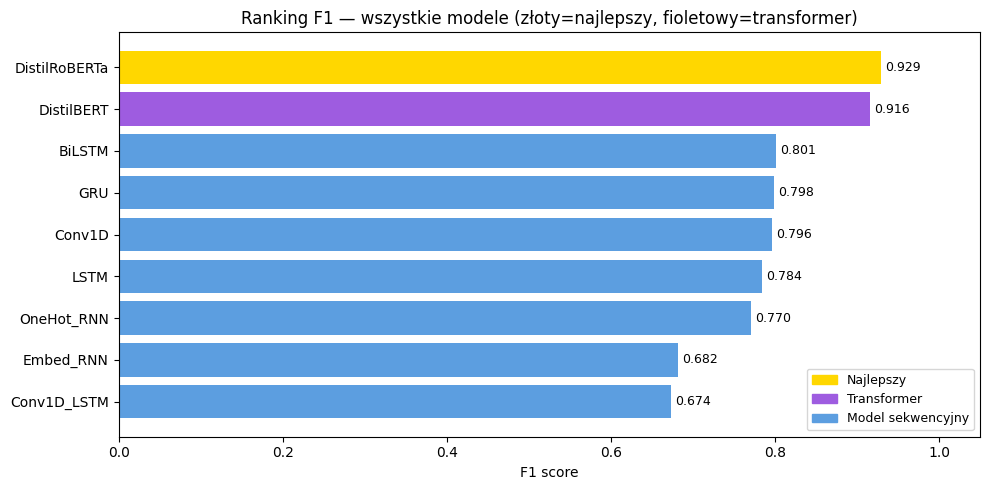

In [69]:
# ---- F1 ranking horyzontalny — wszystkie modele ----
fig, ax = plt.subplots(figsize=(10, max(5, len(comp_df_full) * 0.45)))

def bar_color(model):
    if model == comp_df_full.iloc[0]["Model"]:
        return "#FFD700"   # złoty = najlepszy
    if "distil" in model.lower():
        return "#9e5ce0"   # fioletowy = transformer
    return "#5c9ee0"       # niebieski = model sekwencyjny

colors_rank = [bar_color(m) for m in comp_df_full["Model"][::-1]]
ax.barh(comp_df_full["Model"][::-1], comp_df_full["F1"][::-1], color=colors_rank)
ax.set_xlabel("F1 score")
ax.set_title("Ranking F1 — wszystkie modele (złoty=najlepszy, fioletowy=transformer)")
ax.set_xlim(0, 1.05)
for i, (val, mod) in enumerate(zip(comp_df_full["F1"][::-1], comp_df_full["Model"][::-1])):
    ax.text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)

import matplotlib.patches as mpatches
legend_els = [mpatches.Patch(color="#FFD700", label="Najlepszy"),
              mpatches.Patch(color="#9e5ce0", label="Transformer"),
              mpatches.Patch(color="#5c9ee0", label="Model sekwencyjny")]
ax.legend(handles=legend_els, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "f1_ranking_final.png"), dpi=120, bbox_inches="tight")
plt.show()


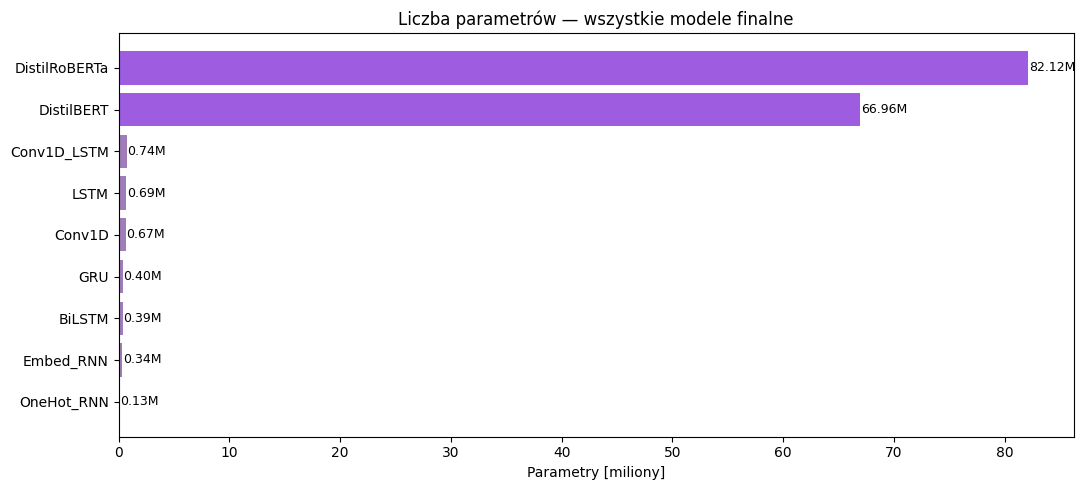

In [70]:
# Liczba parametrów wszystkich modeli finalnych
param_counts = {}
for name, m in [
    ("OneHot_RNN",   model_oh_rnn),
    ("Embed_RNN",    model_emb_rnn),
    ("GRU",          model_gru),
    ("LSTM",         model_lstm),
    ("BiLSTM",       model_bilstm),
    ("Conv1D",       model_conv),
    ("Conv1D_LSTM",  model_conv_lstm),
]:
    param_counts[name] = m.count_params()

param_counts["DistilBERT"]    = sum(p.numel() for p in bert_model.parameters())
param_counts["DistilRoBERTa"] = sum(p.numel() for p in roberta_model.parameters())

pc_df = (pd.DataFrame(list(param_counts.items()), columns=["Model", "Parameters"])
           .sort_values("Parameters"))

fig, ax = plt.subplots(figsize=(11, 5))
cols_pc = ["#9e5ce0" if "distil" in m.lower() else "#a07cb8" for m in pc_df["Model"]]
ax.barh(pc_df["Model"], pc_df["Parameters"] / 1e6, color=cols_pc)
ax.set_xlabel("Parametry [miliony]")
ax.set_title("Liczba parametrów — wszystkie modele finalne")
for i, v in enumerate(pc_df["Parameters"]):
    ax.text(v / 1e6 + 0.05, i, f"{v/1e6:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "param_count_final.png"), dpi=120, bbox_inches="tight")
plt.show()


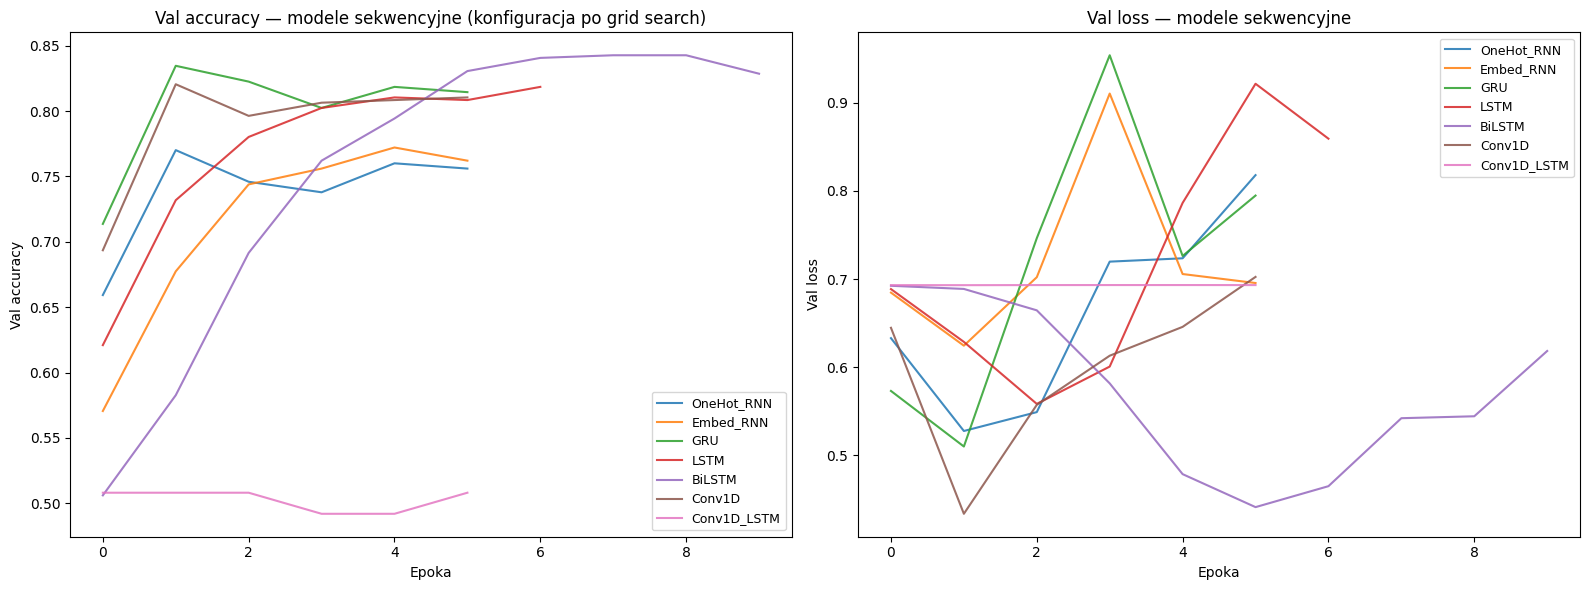

In [71]:
# ---- Learning curves overlay — wszystkie modele finalne ----
keras_histories = {
    "OneHot_RNN":  hist_oh_rnn,
    "Embed_RNN":   hist_emb_rnn,
    "GRU":         hist_gru,
    "LSTM":        hist_lstm,
    "BiLSTM":      hist_bilstm,
    "Conv1D":      hist_conv,
    "Conv1D_LSTM": hist_conv_lstm,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in keras_histories.items():
    axes[0].plot(h.history["val_accuracy"], label=name, alpha=0.85)
    axes[1].plot(h.history["val_loss"],     label=name, alpha=0.85)

axes[0].set_title("Val accuracy — modele sekwencyjne (konfiguracja po grid search)")
axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("Val accuracy")
axes[0].legend(fontsize=9)

axes[1].set_title("Val loss — modele sekwencyjne")
axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("Val loss")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "learning_curves_final.png"), dpi=120, bbox_inches="tight")
plt.show()


## 12. Podsumowanie i wnioski

### Porównanie kodowań
| Kodowanie | Model | Uwagi |
|-----------|-------|-------|
| One-hot | SimpleRNN | Rzadkie, pamięciochłonne, brak semantyki; najsłabszy punkt bazowy |
| Uczone embeddingi | RNN / GRU / LSTM / Conv1D | Gęste, podobieństwo semantyczne uczone podczas trenowania |
| Wstępnie trenowane kontekstowe | DistilBERT, DistilRoBERTa | Najbogatsza reprezentacja; uchwytuje kolejność słów, negację, ironię |

### Porównanie architektur
| Model | Zalety | Wady | Najlepsze zastosowanie |
|-------|--------|------|------------------------|
| SimpleRNN | Prosty, mało parametrów | Zanikający gradient, krótka pamięć | Praktycznie nigdy |
| GRU | Szybki, konkurencyjna dokładność | Nieco mniej pojemny niż LSTM | Krótkie teksty, szybkie prototypowanie |
| LSTM | Silna pamięć długoterminowa | Więcej parametrów, wolniejszy | Ogólne zadania sekwencyjne |
| BiLSTM | Pełny kontekst, najlepsza dokładność rekurencyjna | Podwójna liczba parametrów względem LSTM | Klasyfikacja tekstu, NER |
| Conv1D | Bardzo szybki, dobry do wykrywania n-gramów | Brak globalnego kontekstu | Klasyfikacja krótkich tekstów |
| Conv1D+LSTM | Lokalne cechy + pamięć temporalna | Bardziej złożony pipeline | Najlepsza opcja bez pre-trenowania |
| DistilBERT | Wstępnie trenowany, kontekstowy | Ciężki, wymaga GPU | Produkcyjne zadania NLP |
| DistilRoBERTa | Lepszy pre-trening niż DistilBERT | Nieco wolniejsza tokenizacja | Gdy liczy się każdy punkt F1 |

### Kluczowe wnioski z przeszukiwania hiperparametrów
1. **Heatmapy embed_dim × hidden_dim** ujawniają wyraźne optimum dla każdego modelu
2. **Embed dim** więcej wymiarów = lepiej
3. **Batch size 32** generalnie lepiej generalizuje niż 64 dla modeli rekurencyjnych.
4. **DistilRoBERTa vs DistilBERT**: różnica minimalna między nimi, ale oba lepsze od pozostalych modeli
5. Najlepszy stosunek accuracy do czasu trenowania ma model **conv1D**
